In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:64,garbage_collection_threshold:0.6"

import sys
import gtfparse
from matplotlib.backend_bases import NonGuiException
import numpy as np
import pandas as pd
from pathlib import Path
import logging
import json
import muon as mu
from sklearn.metrics import roc_auc_score

import torch
import argparse

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER")
sys.path.append(str(PROJECT_DIR))

DATA_DIR = PROJECT_DIR.parent / "data"
CHKPT_DIR = PROJECT_DIR / "checkpoints"

import utils
from utils import prepare_tftg_lookup_tables, build_tftg_inputs

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

2026-09-18 10:26:26.054167: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-18 10:26:32.087416: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/muon/_core/preproc.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


# Model Evaluation

### Load WandB Training Logs

In [ ]:
import wandb
api = wandb.Api()

run_id = "ka2czt9l"

run = api.run(f"luminarada-penn-state-health/celltype-TF-TG/{run_id}")

# Load the final summary metrics from the run
training_summary = pd.DataFrame.from_dict(run.summary_metrics, orient="index").reset_index().rename(columns={"index": "Metric", 0: "Value"})
display(training_summary)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /gpfs/Home/esm5360/.netrc.


,Metric,Value
0,_runtime,5.373232e+04
1,_step,1.039400e+04
2,_timestamp,1.789666e+09
3,_wandb.runtime,5.373200e+04
4,epoch,2.000000e+01
5,lr-AdamW,1.000000e-04
6,train/acc,7.572306e-01
7,train/loss_epoch,5.057949e-01
8,train/loss_step,5.177988e-01
9,trainer/global_step,1.033290e+05


In [ ]:
# Load the run training history
rows = run.scan_history(
    page_size=10_000,
)
run_history = pd.DataFrame(rows)

In [ ]:
sample_list = {}
for dataset_item in run.config["dataset"]:
    sample_items = dataset_item.split(":")
    tissue, sample = sample_items[0], sample_items[1]
    if "tissue" not in sample_list:
        sample_list["tissue"] = []
    if "sample" not in sample_list:
        sample_list["sample"] = []
    sample_list["tissue"].append(tissue)
    sample_list["sample"].append(sample)

holdout_celltypes = run.config["holdout_celltype"]
holdout_samples = run.config["holdout_sample"]

print(f"Samples:")
for tissue, sample in zip(sample_list["tissue"], sample_list["sample"]):
    print(f"  - {tissue}: {sample}")
    
    train_celltypes = run.config[f"{tissue}__{sample}_train_celltypes"]
    for celltype in train_celltypes:
        print(f"    - {celltype}")
    
print()
print("Held-out cell types and samples:")    
print(f"  - Held-out cell types: {holdout_celltypes}")
print(f"  - Held-out samples: {holdout_samples}")

Samples:
  - mouse_liver: liver_sample
    - Endothelial
    - Hepatocytes
    - T cells
  - mESC: E7.5_rep1
    - Blood_progenitors
    - Epiblast_lineage
    - ExE_ectoderm
    - ExE_endoderm_lineage
    - Mesenchyme
    - Mesoderm_lineage
    - Surface_ectoderm

Held-out cell types and samples:
  - Held-out cell types: ['Neurectoderm', 'Fibroblasts']
  - Held-out samples: []


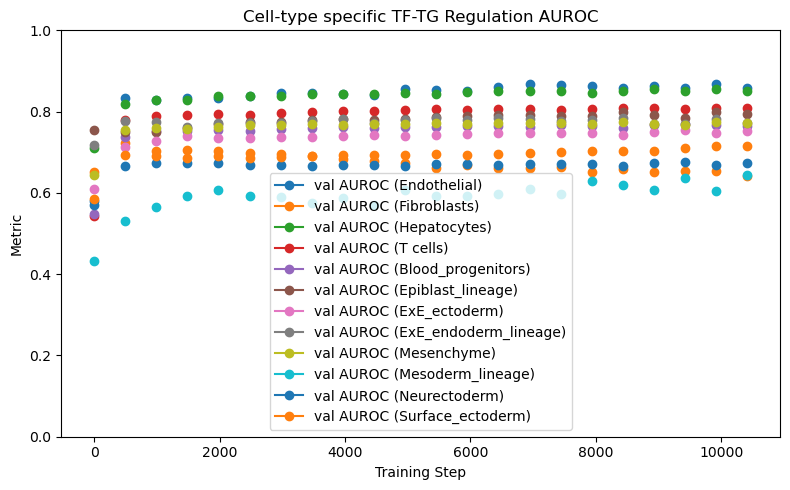

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(figsize=(8, 5))

split = "val"

celltype_metric_name_map = {}
for tissue, sample in sample_list:
    split_celltypes = run.config[f"{tissue}__{sample}_{split}_celltypes"]
    
    split_metric_naming_convention = f"{split}/sample/{sample}/celltype/{{celltype}}/auroc"
    for celltype in split_celltypes:
        celltype_metric_name_map[celltype] =  split_metric_naming_convention.format(celltype=celltype)

for celltype, metric_name in celltype_metric_name_map.items():
    axes.plot(
        run_history["_step"],
        run_history[metric_name],
        marker="o",
        label=f"{split} AUROC ({celltype})",
    )

axes.set_title("Cell-type specific TF-TG Regulation AUROC")
axes.set_xlabel("Training Step")
axes.set_ylabel("Metric")
axes.set_ylim(0, 1)
axes.legend()

plt.tight_layout()

### Load Trained Model from Checkpoint

In [ ]:
import models.tf_to_tg_celltype as tf_to_tg_module
import models.tf_to_dna as tf_to_dna_module

def gpu_supports_torch_compile(device):
    if device.type != "cuda":
        return False

    major, minor = torch.cuda.get_device_capability(device)
    return major >= 7

def strip_compiled_prefix_from_state_dict(state_dict, prefix="_orig_mod."):
    """
    Remove torch.compile's _orig_mod prefix from state_dict keys.

    Examples:
        model._orig_mod.encoder.weight -> model.encoder.weight
        _orig_mod.encoder.weight       -> encoder.weight
    """
    cleaned = {}

    for key, value in state_dict.items():
        cleaned_key = key.replace(prefix, "")
        cleaned[cleaned_key] = value

    return cleaned

def load_tf_tg_regulation_model(
    tf_dna_model_path: Path,
    tf_tg_model_path: Path,
    tf_embeddings_tensor: torch.Tensor,
    tf_mask_tensor: torch.Tensor,
    compile_model: bool = False,
    device: torch.device | None = None,
    model_module=None,
) -> tf_to_tg_module.LitTFTGRegulationModel:
    """
    model_module lets a caller load a checkpoint trained against a different
    TFTGRegulationModel definition than the default models.tf_to_tg -- e.g.
    models.tf_to_tg_testing while it is under active architecture changes there.
    Defaults to models.tf_to_tg (unchanged behaviour for every existing checkpoint).
    """
    model_module = model_module or tf_to_tg_module

    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if compile_model and not gpu_supports_torch_compile(device):
        if device.type == "cuda":
            major, minor = torch.cuda.get_device_capability(device)
            logging.warning(
                f"Skipping torch.compile because this GPU has compute capability "
                f"{major}.{minor}; Inductor/Triton requires >= 7.0."
            )
        else:
            logging.warning("Skipping torch.compile because device is not CUDA.")

        compile_model = False

    # -----------------------------
    # 1. Recreate base TF-DNA model uncompiled
    # -----------------------------
    base_model = tf_to_dna_module.TFPeakBindingModel(
        tf_embedding_dim=128,
        hidden_dim=128,
        dropout=0.3,
        num_layers=4,
        num_heads=4,
        dim_head=32,
    )

    # -----------------------------
    # 2. Load TF-DNA checkpoint
    # -----------------------------
    tf_dna_ckpt = torch.load(
        tf_dna_model_path,
        map_location="cpu",
        weights_only=False,
    )

    tf_dna_state_dict = tf_dna_ckpt["state_dict"]

    if any("._orig_mod." in key or key.startswith("_orig_mod.") for key in tf_dna_state_dict):
        logging.info("Detected compiled TF-DNA checkpoint. Stripping _orig_mod prefixes.")
        tf_dna_state_dict = strip_compiled_prefix_from_state_dict(tf_dna_state_dict)

    lit_tf_dna_model = tf_to_dna_module.LitTFPeakBindingModel(
        model=base_model,
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        lr=1e-4,
        weight_decay=1e-4,
        pos_weight=None,
    )

    lit_tf_dna_model.load_state_dict(tf_dna_state_dict, strict=True)

    trained_tf_peak_model = lit_tf_dna_model.model
    trained_tf_peak_model.eval()

    for p in trained_tf_peak_model.parameters():
        p.requires_grad = False

    # -----------------------------
    # 3. Load TF-TG checkpoint
    # -----------------------------
    # load_from_checkpoint reconstructs the train-fitted expression and ATAC
    # scaler values from hyper_parameters. Loading only state_dict would silently
    # restore the default mean=0/std=1 because those scaler buffers are non-persistent.
    lit_tf_tg_model = model_module.LitTFTGRegulationModel.load_from_checkpoint(
        str(tf_tg_model_path), map_location="cpu",
    )
    lit_tf_tg_model.eval()

    for p in lit_tf_tg_model.parameters():
        p.requires_grad = False

    # -----------------------------
    # 5. Optional compile after loading
    # -----------------------------
    if compile_model:
        logging.info("Compiling loaded TF-TG core model.")
        lit_tf_tg_model.model = torch.compile(lit_tf_tg_model.model)

    # Evaluation needs the frozen TF-DNA model to recreate the binding scores.
    return lit_tf_tg_model, trained_tf_peak_model

In [4]:
species = "mm10"

mm10_tf_dna_path = CHKPT_DIR / "new_tf_dna_models" / "mm10_3831017_epoch_12.ckpt"
model_checkpoint = CHKPT_DIR / "celltype_tf_tg" / "celltype_joint_3881696_20260916_181748_296478" / "checkpoints" / "last.ckpt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tf_dna_input_cache_dir = PROJECT_DIR / "cached_data" / species / "tf_dna_cache"
tf_embedding_cache_path = tf_dna_input_cache_dir / "tf_embeddings.pt"
tf_mask_cache_path = tf_dna_input_cache_dir / "tf_masks.pt"

tf_embeddings_tensor = torch.load(tf_embedding_cache_path, weights_only=True)
tf_mask_tensor = torch.load(tf_mask_cache_path, weights_only=True)

trained_model, trained_tf_peak_model = load_tf_tg_regulation_model(
    tf_dna_model_path=mm10_tf_dna_path,
    tf_tg_model_path=model_checkpoint,
    tf_embeddings_tensor= tf_embeddings_tensor,
    tf_mask_tensor= tf_mask_tensor,
    compile_model=False,
    device=device,
    model_module=tf_to_tg_module,
)

trained_model

LitTFTGRegulationModel(
  (model): SimpleTFTGRegulationModel(
    (peak_feature_proj): Sequential(
      (0): Linear(in_features=4, out_features=128, bias=True)
      (1): SiLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=128, out_features=128, bias=True)
    )
    (tf_expr_proj): Sequential(
      (0): Linear(in_features=1, out_features=128, bias=True)
      (1): SiLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
    )
    (tg_expr_proj): Sequential(
      (0): Linear(in_features=1, out_features=128, bias=True)
      (1): SiLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
    )
    (tg_query_proj): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): SiLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
    )
    (peak_attention): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
    )
    (norm): Layer

### Load Trained Model Data

In [5]:
def load_model_data(model_checkpoint: Path, split_name: str = "test"):
    """Load and concatenate every cached source used by a trained run."""
    logging.info(f"Loading model data for checkpoint {model_checkpoint} and split {split_name}")
    from torch.utils.data import ConcatDataset, DataLoader
    from scripts.train_tf_to_tg_celltype_model import (
        binding_score_cache_path,
        TFTGEdgeBagDataset,
    )

    def load_run_config(model_checkpoint: Path):
        run_dir = model_checkpoint.parent.parent
        with open(run_dir / "run_config.json") as handle:
            return json.load(handle)

    def source_specs(run_config):
        configured = run_config.get("dataset")
        if not configured:
            configured = [f"{run_config['tissue']}:{run_config['sample_name']}"]
        if isinstance(configured, str):
            configured = [configured]
        return [tuple(value.split(":", 1)) for value in configured]

    def load_multiome_data(run_config, tissue, sample_name):
        """
        Recreate the RNA and ATAC matrix order. 
        """
        
        eval_data_dir = Path(run_config["data_dir"])
        eval_mdata = mu.read(
            eval_data_dir / "processed" / tissue
            / sample_name / "multiome_processed.h5mu"
        )
        eval_rna = eval_mdata.mod["rna"]
        eval_atac = eval_mdata.mod["atac"]
        shared_cells = eval_rna.obs_names[eval_rna.obs_names.isin(eval_atac.obs_names)]
        eval_rna = eval_rna[shared_cells].copy()
        eval_atac = eval_atac[shared_cells].copy()

        max_autosome = 19 if run_config["species"] == "mm10" else 22
        valid_chroms = {f"chr{i}" for i in range(1, max_autosome + 1)}
        keep_peaks = np.array([
            peak.split(":", 1)[0] in valid_chroms for peak in eval_atac.var_names
        ])
        eval_atac = eval_atac[:, keep_peaks].copy()
        eval_rna.var_names = eval_rna.var_names.str.upper()
        
        return eval_rna, eval_atac

    def load_cell_pools(source_dir):
        with open(source_dir / "prepared_manifest.json") as handle:
            manifest = json.load(handle)
        cell_pools = {}
        with np.load(source_dir / "cell_pools.npz", allow_pickle=False) as archive:
            for pool in manifest["outputs"]["cell_pools"]:
                cell_pools[(pool["sample_id"], pool["cell_type"])] = (
                    archive[pool["array_key"]].astype(np.int64, copy=False)
                )
        return cell_pools

    def check_dataset_indices_match(split_df, eval_rna, atac_mat, atac_peak_tensor):
        # Fail early if the source MuData has changed since training data preparation.
        rna_names = eval_rna.var_names.to_numpy()
        assert np.array_equal(
            rna_names[split_df["tf_rna_col"].to_numpy()], split_df["tf_name"].to_numpy()
        )
        assert np.array_equal(
            rna_names[split_df["tg_rna_col"].to_numpy()], split_df["tg_id"].to_numpy()
        )
        assert atac_mat.shape[1] == atac_peak_tensor.shape[0]

    def load_binding_scores(source_dir, split_df, run_config, tissue, sample_name):
        canonical_path = binding_score_cache_path(
            source_dir / "prepared", split_name, split_df,
            tf_dna_checkpoint=run_config["tf_dna_checkpoint"],
            max_peaks_per_tg=run_config["max_peaks_per_tg"],
        )
        config_key = f"{tissue}__{sample_name}_{split_name}_binding_cache"
        configured_path = Path(run_config.get(config_key, canonical_path))
        binding_path = canonical_path if canonical_path.exists() else configured_path
        if not binding_path.exists():
            raise FileNotFoundError(f"Binding scores not found at {binding_path}")
        binding_scores = torch.load(binding_path, map_location="cpu", weights_only=True)
        expected_shape = (len(split_df), run_config["max_peaks_per_tg"])
        if tuple(binding_scores.shape) != expected_shape:
            raise ValueError(
                f"{binding_path} has shape {tuple(binding_scores.shape)}; "
                f"expected {expected_shape}"
            )
        return binding_scores

    logging.info(f"  - Loading config")
    run_config = load_run_config(model_checkpoint)
    
    if split_name not in {"train", "val", "test"}:
        raise ValueError(f"Invalid split name: {split_name}")
    cache_dir = Path(run_config["cache_dir"])
    scaler_path = Path(run_config.get("input_scaler_path", cache_dir / "input_scaler.json"))
    with open(scaler_path) as handle:
        cached_scaler = json.load(handle)
    if cached_scaler != run_config.get("input_scaler"):
        raise ValueError("Cached scaler does not match this run's saved scaler")

    holdout_samples = set(run_config.get("holdout_sample", []))
    holdout_celltypes = set(run_config.get("holdout_celltype", []))
    dataset_parts = []
    source_edge_counts = {}
    for tissue, sample_name in source_specs(run_config):
        source_key = f"{tissue}__{sample_name}"
        if split_name == "train" and f"{tissue}:{sample_name}" in holdout_samples:
            logging.info(f"  - Skipping held-out training source {tissue}:{sample_name}")
            continue
        source_dir = cache_dir / "prepared_sources" / source_key
        if not source_dir.is_dir():
            raise FileNotFoundError(f"Prepared source cache not found: {source_dir}")

        logging.info(f"  - Loading {split_name} data for {tissue}:{sample_name}")
        split_df = pd.read_parquet(source_dir / f"edges_{split_name}.parquet")
        if split_name == "train" and holdout_celltypes:
            split_df = split_df.loc[
                ~split_df["cell_type"].isin(holdout_celltypes)
            ].reset_index(drop=True)
        if split_df.empty:
            continue

        atac_peak_tensor = torch.load(
            source_dir / "prepared" / sample_name / "atac_peak_tensor.pt",
            map_location="cpu", weights_only=True,
        )
        eval_rna, eval_atac = load_multiome_data(run_config, tissue, sample_name)
        rna_mat, atac_mat = eval_rna.X, eval_atac.X
        cell_pools = load_cell_pools(source_dir)
        check_dataset_indices_match(split_df, eval_rna, atac_mat, atac_peak_tensor)
        split_binding_scores = load_binding_scores(
            source_dir, split_df, run_config, tissue, sample_name
        )
        dataset_parts.append(TFTGEdgeBagDataset(
            split_df,
            tf_embeddings_tensor=None, tf_mask_tensor=None,
            atac_peak_tensor=atac_peak_tensor, atac_mat=atac_mat, rna_mat=rna_mat,
            cell_pools=cell_pools,
            max_peaks_per_tg=run_config["max_peaks_per_tg"],
            resample_max_cells_per_pair=run_config["max_cells_per_pair"],
            resample_cells=False, binding_scores=split_binding_scores,
            seed=run_config["seed"],
        ))
        source_edge_counts[f"{tissue}:{sample_name}"] = len(split_df)

    if not dataset_parts:
        raise ValueError(f"No {split_name} datasets were available")
    split_dataset = (
        dataset_parts[0] if len(dataset_parts) == 1 else ConcatDataset(dataset_parts)
    )

    logging.info(f"  - Creating dataloader")
    split_dataloader = DataLoader(
        split_dataset, batch_size=run_config["batch_size"], shuffle=False,
        num_workers=run_config["num_workers"],
        persistent_workers=run_config["num_workers"] > 0,
        pin_memory=device.type == "cuda", drop_last=False,
    )
    
    print(
        f"Loaded {len(split_dataset):,} {split_name} edges from "
        f"{source_edge_counts} in {len(split_dataloader):,} batches. "
        "Inputs remain unscaled; the checkpoint model applies its saved scaler."
    )
    
    return split_dataset, split_dataloader, run_config

test_dataset, test_dataloader, test_run_config = load_model_data(
    model_checkpoint=model_checkpoint, split_name="test"
)

INFO:root:Loading model data for checkpoint /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER/checkpoints/celltype_tf_tg/celltype_joint_3881696_20260916_181748_296478/checkpoints/last.ckpt and split test
INFO:root:  - Loading config
INFO:root:  - Loading test data for mouse_liver:liver_sample
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.se

Loaded 248,010 test edges from {'mouse_liver:liver_sample': 86667, 'mESC:E7.5_rep1': 161343} in 485 batches. Inputs remain unscaled; the checkpoint model applies its saved scaler.


### Evaluate own test set

In [6]:
import torch.nn as nn
from tqdm import tqdm

def run_batch(trained_model, batch_cpu, train: bool, microbatch_size: int = 64):
    """One batch, microbatched. Returns (loss, edge_logits, labels), all on CPU."""
    B = len(batch_cpu["label"])
    
    gpu_keys = [
        "binding_score", "peak_accessibility", "peak_distance",
        "tf_expression", "tg_expression", "cell_mask", "peak_mask", "label",
    ]

    edge_parts, total_loss = [], 0.0
    for start in range(0, B, microbatch_size):
        end = min(start + microbatch_size, B)
        microbatch = {k: batch_cpu[k][start:end].to(device) for k in gpu_keys}

        with torch.set_grad_enabled(train):
            edge_logits, _ = trained_model(microbatch)
            loss = nn.functional.binary_cross_entropy_with_logits(
                edge_logits, microbatch["label"].float(), reduction="sum",
            ) / B

        if train:
            loss.backward()

        total_loss += loss.item()
        edge_parts.append(edge_logits.detach().cpu())
        del microbatch, edge_logits, loss

    return total_loss, torch.cat(edge_parts), batch_cpu["label"].float()


@torch.no_grad()
def evaluate(model, loader, desc="Evaluating"):
    model.eval()

    logits, labels = [], []
    loss_sum = 0.0
    n = 0

    progress = tqdm(
        loader,
        desc=desc,
        total=len(loader),
        unit="batch",
        dynamic_ncols=True,
    )

    for batch_cpu in progress:
        b = len(batch_cpu["label"])

        # run_batch already manages gradient mode.
        loss, edge_logits, y = run_batch(
            model,
            batch_cpu,
            train=False,
        )

        # run_batch returns mean loss over this batch.
        loss_sum += loss * b
        n += b

        logits.append(edge_logits)
        labels.append(y)

        progress.set_postfix(
            loss=f"{loss_sum / n:.4f}",
            edges=n,
        )

    logits = torch.cat(logits)
    labels = torch.cat(labels)
    probabilities = logits.sigmoid()
    avg_loss = loss_sum / n

    if labels.min() != labels.max():
        auroc = roc_auc_score(
            labels.numpy(),
            probabilities.numpy(),
        )
    else:
        auroc = float("nan")

    return avg_loss, auroc, probabilities, labels

trained_model = trained_model.to(device)
eval_loss, eval_auroc, eval_probs, eval_labels = evaluate(trained_model, test_dataloader)


In [7]:
inputs = pd.concat([ds.inputs for ds in test_dataset.datasets], ignore_index=True)
test_set_predictions = inputs[[
    "cell_type", "tf_name", "tg_id", "label"
]].copy()
test_set_predictions["probability"] = eval_probs.numpy()
test_set_predictions["predicted_label"] = (
    test_set_predictions["probability"] >= 0.5
).astype(np.int8)

display(test_set_predictions.head(10))

,cell_type,tf_name,tg_id,label,probability,predicted_label
0,Hepatocytes,FOXA2,GM36602,False,0.568570,1
1,Fibroblasts,FOXA3,VWCE,True,0.001707,0
2,Hepatocytes,SETDB1,GM45871,True,0.030800,0
3,T cells,STAT1,RAB18,True,0.824767,1
4,Hepatocytes,CREB1,LZTS2,True,0.834209,1
5,Fibroblasts,EBF1,CCDC68,False,0.278849,0
6,T cells,SOX13,EPB41L4AOS,False,0.067699,0
7,T cells,STAT6,FXN,False,0.230165,0
8,Hepatocytes,FOXA3,ANKRD13D,False,0.123291,0
9,Hepatocytes,NR1D1,A1CF,True,0.445629,0


In [ ]:
grn_columns = ["CellType", "Source", "Target", "Score", "Label"]
evaluation_grn = (
    test_set_predictions
    .rename(columns={
        "cell_type": "CellType",
        "tf_name": "Source",
        "tg_id": "Target",
        "probability": "Score",
        "label": "Label"
    })
    .loc[:, grn_columns]
    .assign(
        Source=lambda frame: frame["Source"].astype(str).str.upper(),
        Target=lambda frame: frame["Target"].astype(str).str.upper(),
    )
)

display(evaluation_grn.head())

,CellType,Source,Target,Score,Label
0,Hepatocytes,FOXA2,GM36602,0.568570,False
1,Fibroblasts,FOXA3,VWCE,0.001707,True
2,Hepatocytes,SETDB1,GM45871,0.030800,True
3,T cells,STAT1,RAB18,0.824767,True
4,Hepatocytes,CREB1,LZTS2,0.834209,True


### Load Other Method Cell Type Specific GRNs and label

In [22]:
from pathlib import Path

import pandas as pd


other_method_grn_dir = Path(
    "/gpfs/Labs/Uzun/DATA/PROJECTS/"
    "2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/"
    "other_method_celltype_grns"
)

cell_type_specific_gt_dir = (
    DATA_DIR / "ground_truth_files" / "cell_type_specific"
)
species_gt_dir = cell_type_specific_gt_dir / species


# ---------------------------------------------------------
# INDEX FILES ONCE
# This is particularly useful on GPFS, where repeated rglob
# calls can be relatively expensive.
# ---------------------------------------------------------
method_dirs = sorted(
    path for path in other_method_grn_dir.iterdir()
    if path.is_dir()
)

method_file_index = {
    method_dir.name: list(method_dir.rglob("*.tsv"))
    for method_dir in method_dirs
}

gt_file_index = {
    path.name: path
    for path in species_gt_dir.rglob("*_ground_truth.parquet")
}


# ---------------------------------------------------------
# LOAD EACH CELL-TYPE GROUND TRUTH ONLY ONCE
# ---------------------------------------------------------
gt_cache = {}
method_grns = {}

celltypes = evaluation_grn["CellType"].dropna().unique()

for celltype in celltypes:
    celltype_file_name = celltype.replace(" ", "_")

    gt_filename = f"{celltype_file_name}_ground_truth.parquet"
    gt_path = gt_file_index.get(gt_filename)

    if gt_path is None:
        print(f"No ground truth found for {celltype}")
        continue

    # Load and prepare this cell type's GT once.
    gt = pd.read_parquet(
        gt_path,
        columns=["Source", "Target"],
    )

    gt = (
        gt.assign(
            Source=gt["Source"].astype(str).str.upper(),
            Target=gt["Target"].astype(str).str.upper(),
        )
        .drop_duplicates(["Source", "Target"])
    )

    gt_sources = set(gt["Source"])
    gt_targets = set(gt["Target"])

    # A vectorized edge lookup index.
    gt_edge_index = pd.MultiIndex.from_frame(
        gt[["Source", "Target"]]
    )

    gt_cache[celltype] = {
        "path": gt_path,
        "sources": gt_sources,
        "targets": gt_targets,
        "edges": gt_edge_index,
    }

    for method_dir in method_dirs:
        method_name = method_dir.name
        filename_prefix = (
            f"{method_name.lower()}_{celltype_file_name}_"
        )

        matching_paths = [
            path
            for path in method_file_index[method_name]
            if path.name.lower().startswith(filename_prefix.lower())
        ]

        if not matching_paths:
            continue

        if len(matching_paths) > 1:
            print(
                f"Warning: found {len(matching_paths)} files for "
                f"{method_name}, {celltype}; using {matching_paths[0]}"
            )

        method_grn_path = sorted(matching_paths)[0]
        print(f"Loading: {method_grn_path.name}")

        # Read only required columns.
        other_method_grn = pd.read_csv(
            method_grn_path,
            sep="\t",
            usecols=["Source", "Target", "Score"],
        )

        other_method_grn["Source"] = (
            other_method_grn["Source"].astype(str).str.upper()
        )
        other_method_grn["Target"] = (
            other_method_grn["Target"].astype(str).str.upper()
        )

        # Restrict evaluation to TFs and TGs represented in the GT.
        source_mask = other_method_grn["Source"].isin(gt_sources)
        target_mask = other_method_grn["Target"].isin(gt_targets)

        matching_tfs = other_method_grn.loc[
            source_mask, "Source"
        ].nunique()

        matching_tgs = other_method_grn.loc[
            target_mask, "Target"
        ].nunique()

        print(
            f"  - {method_name} has {matching_tfs} matching TFs "
            f"and {matching_tgs} matching TGs with the ground "
            f"truth for {celltype}."
        )

        other_method_grn = (
            other_method_grn.loc[
                source_mask & target_mask,
                ["Source", "Target", "Score"],
            ]
            .copy()
        )

        # Vectorized edge labeling.
        predicted_edge_index = pd.MultiIndex.from_frame(
            other_method_grn[["Source", "Target"]]
        )

        other_method_grn["Label"] = (
            predicted_edge_index.isin(gt_edge_index).astype("int8")
        )

        other_method_grn.insert(0, "CellType", celltype)

        method_grns[(method_name, celltype)] = other_method_grn


print(f"Loaded {len(method_grns)} method/cell-type GRNs")

display(
    method_grns[("CellOracle", "Hepatocytes")].head()
)

Loading: celloracle_Hepatocytes_liver_sample.tsv
  - CellOracle has 21 matching TFs and 11153 matching TGs with the ground truth for Hepatocytes.
Loading: figr_Hepatocytes_liver_sample.tsv
  - FigR has 20 matching TFs and 7718 matching TGs with the ground truth for Hepatocytes.
Loading: linger_Hepatocytes_liver_sample.tsv
  - LINGER has 21 matching TFs and 375 matching TGs with the ground truth for Hepatocytes.
Loading: pando_Fibroblasts_liver_sample.tsv
  - Pando has 17 matching TFs and 6161 matching TGs with the ground truth for Fibroblasts.
Loading: celloracle_Endothelial_liver_sample.tsv
  - CellOracle has 6 matching TFs and 8458 matching TGs with the ground truth for Endothelial.
Loading: figr_Endothelial_liver_sample.tsv
  - FigR has 6 matching TFs and 5313 matching TGs with the ground truth for Endothelial.
Loading: pando_Endothelial_liver_sample.tsv
  - Pando has 4 matching TFs and 1751 matching TGs with the ground truth for Endothelial.
Loading: celloracle_Blood_progenitors_E7

,CellType,Source,Target,Score,Label
9,Hepatocytes,NR3C1,CES3B,0.462068,0
10,Hepatocytes,CEBPB,HAMP,0.461519,0
23,Hepatocytes,CEBPB,SDS,0.391971,0
26,Hepatocytes,CEBPB,HAL,0.380517,0
39,Hepatocytes,FOXA2,KEG1,0.339610,0


## Cross-trained model vs other inference methods

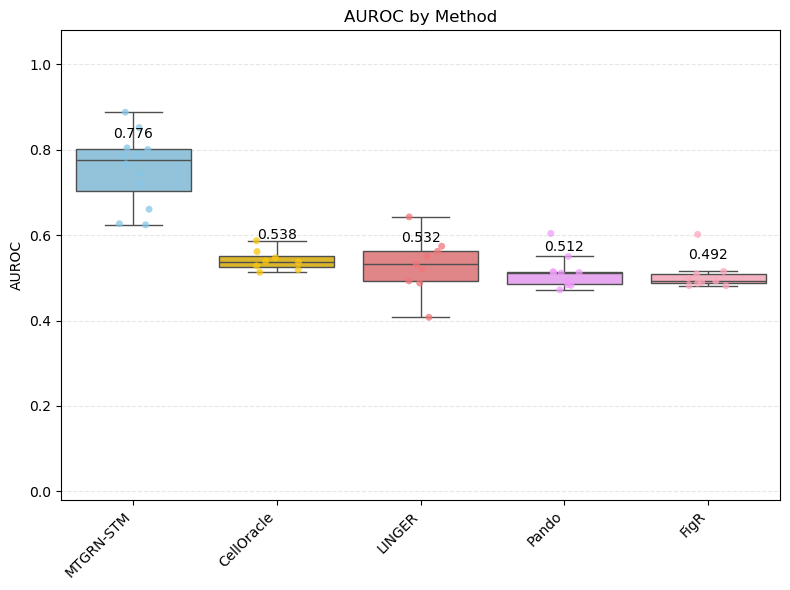

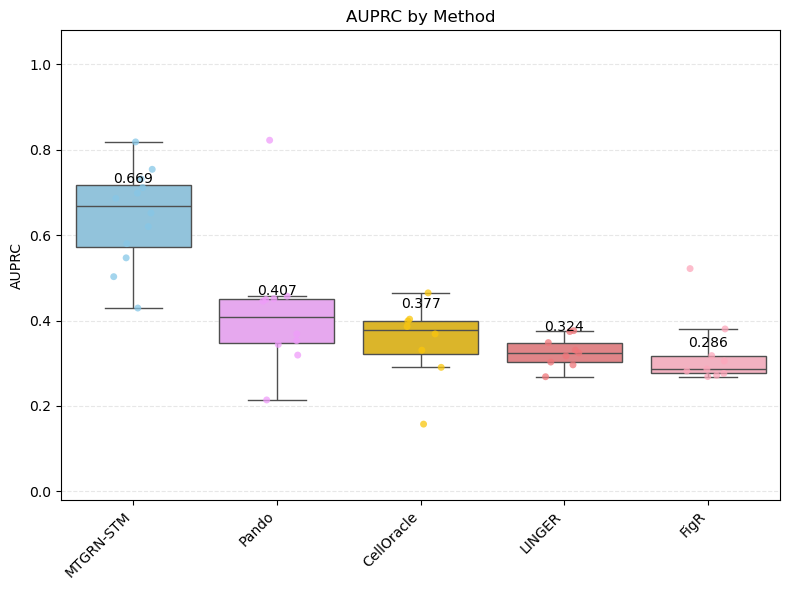

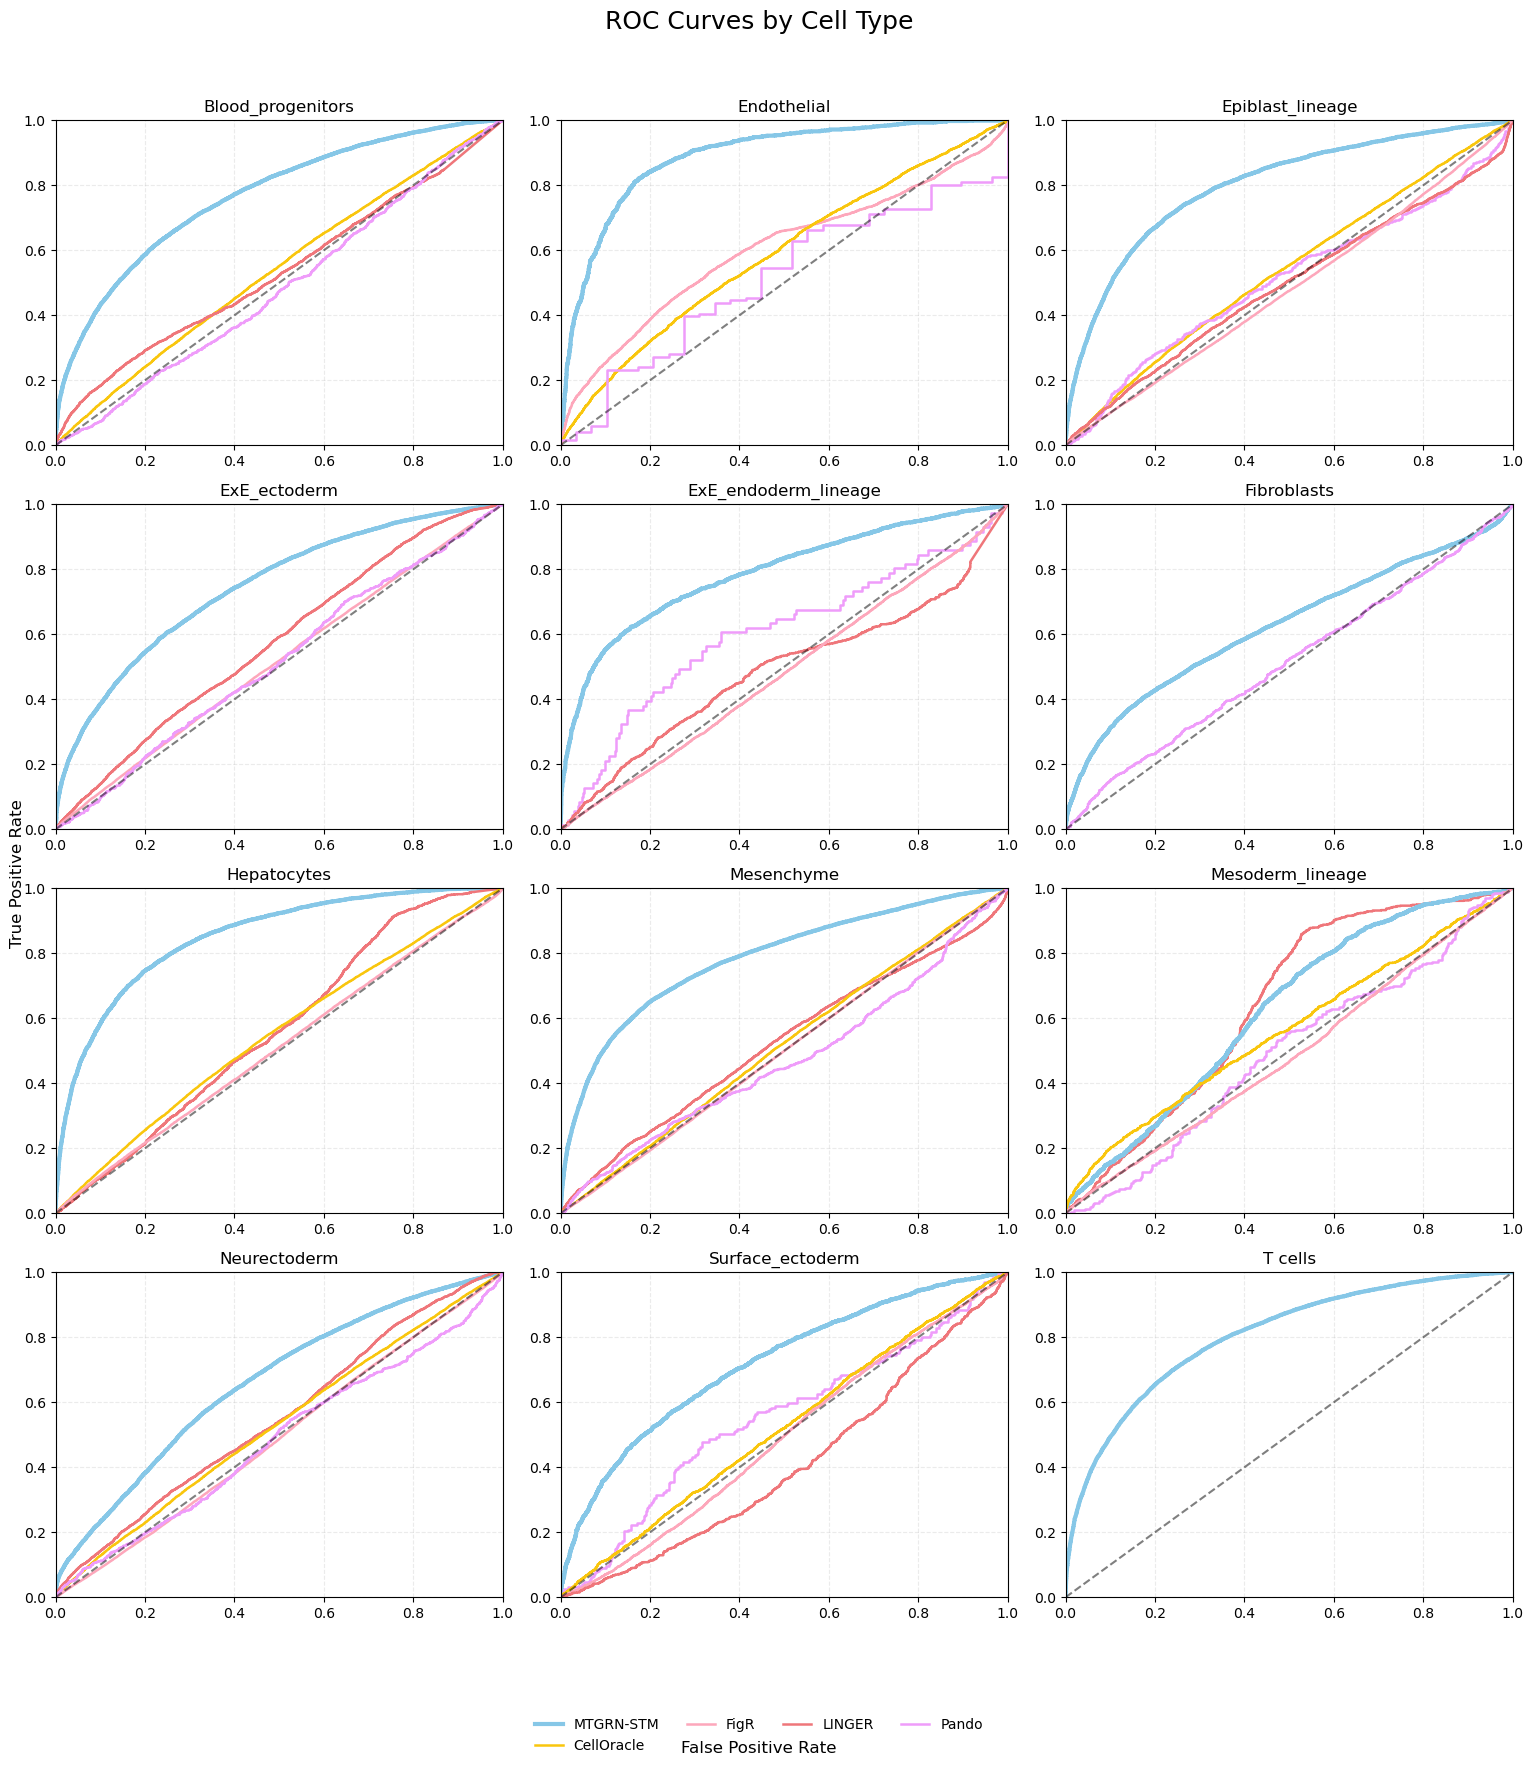

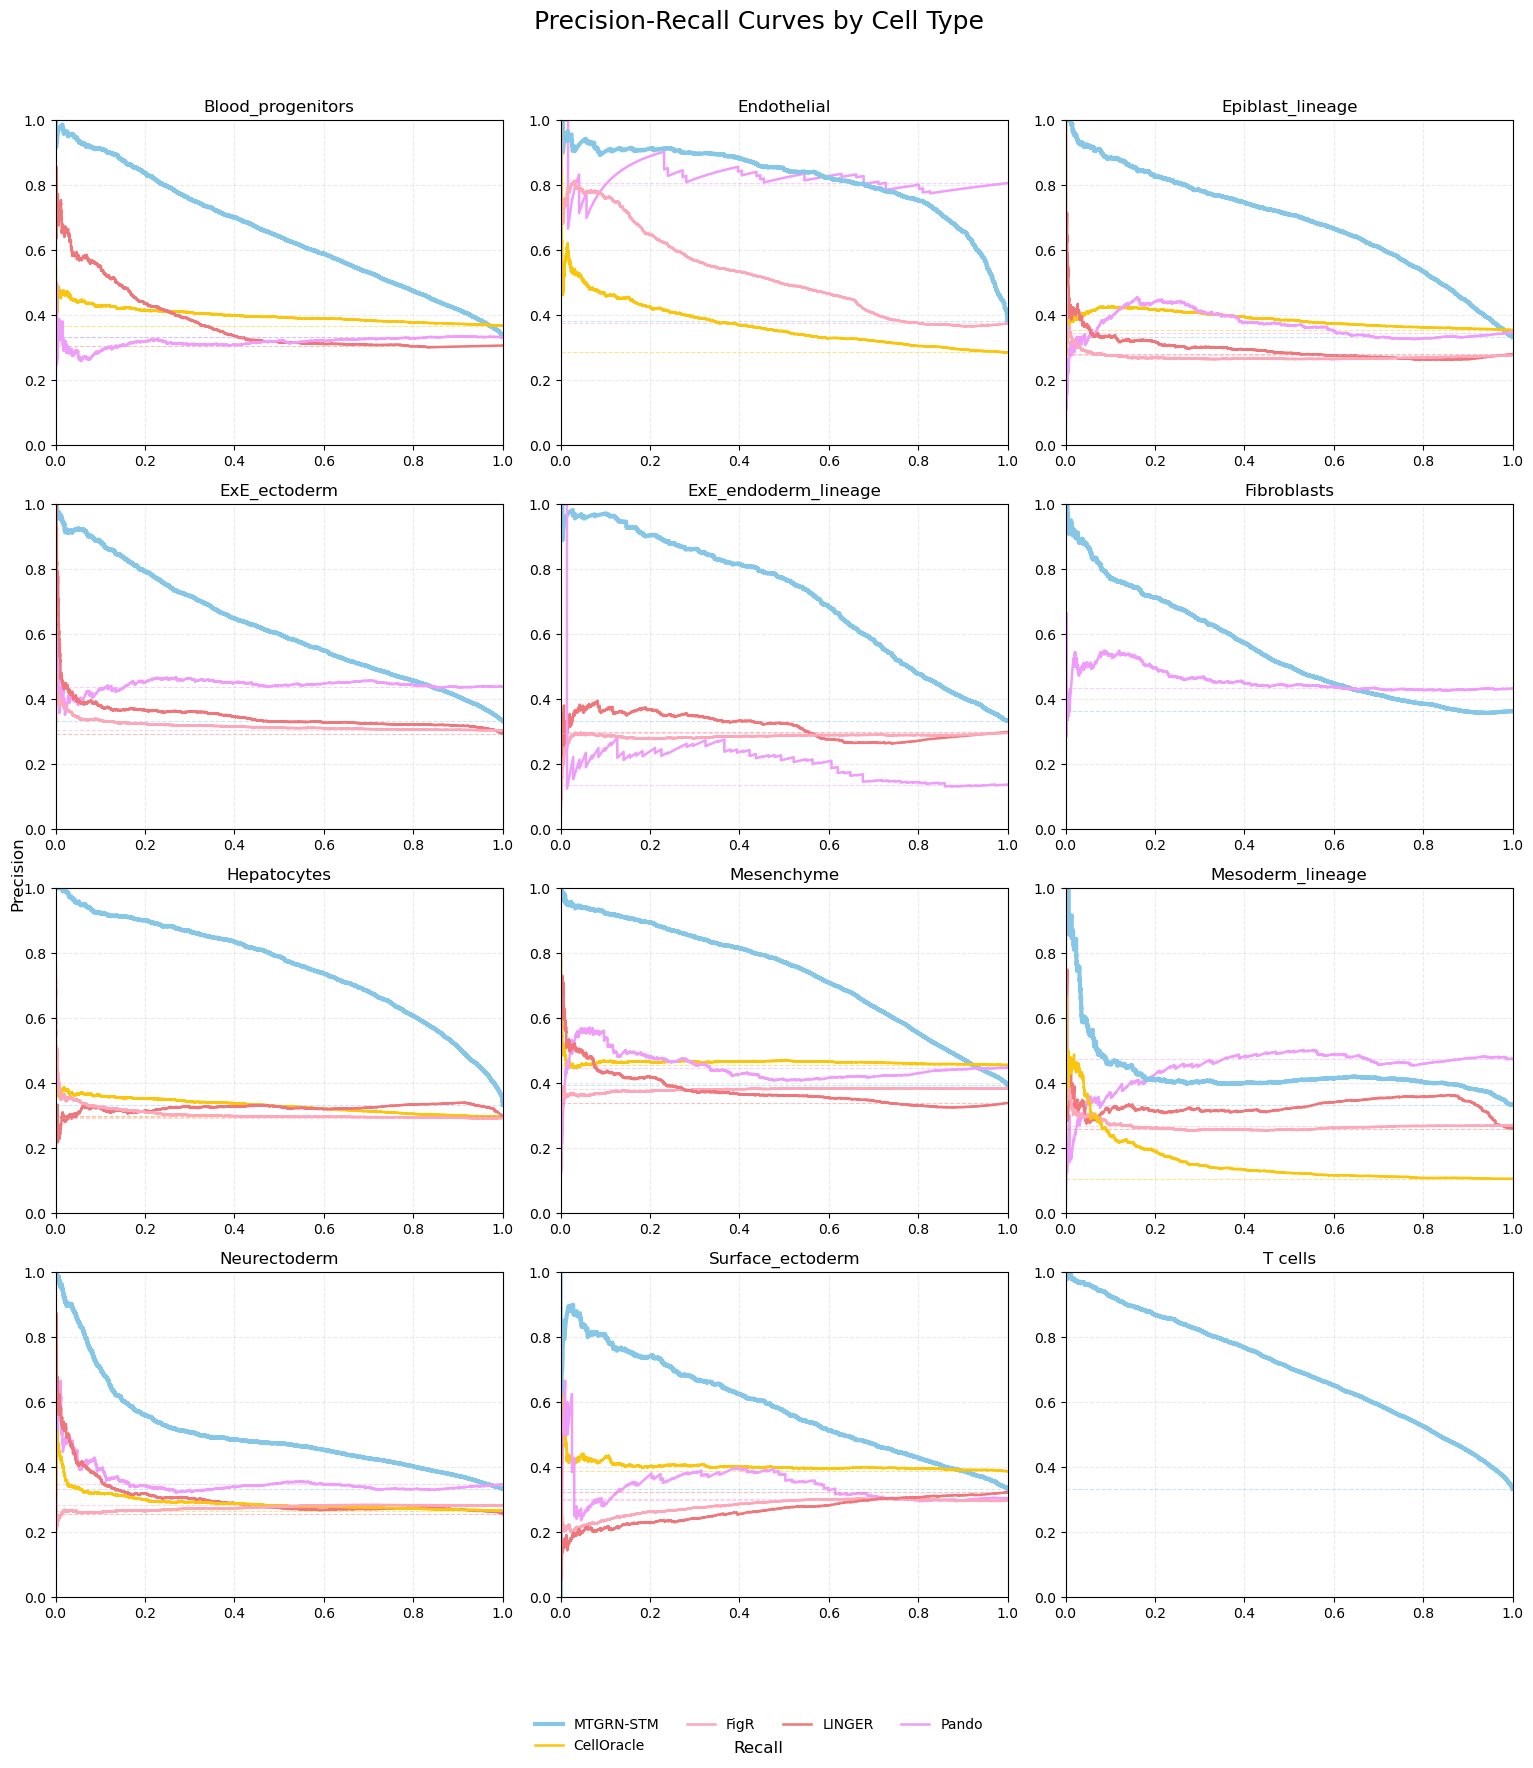

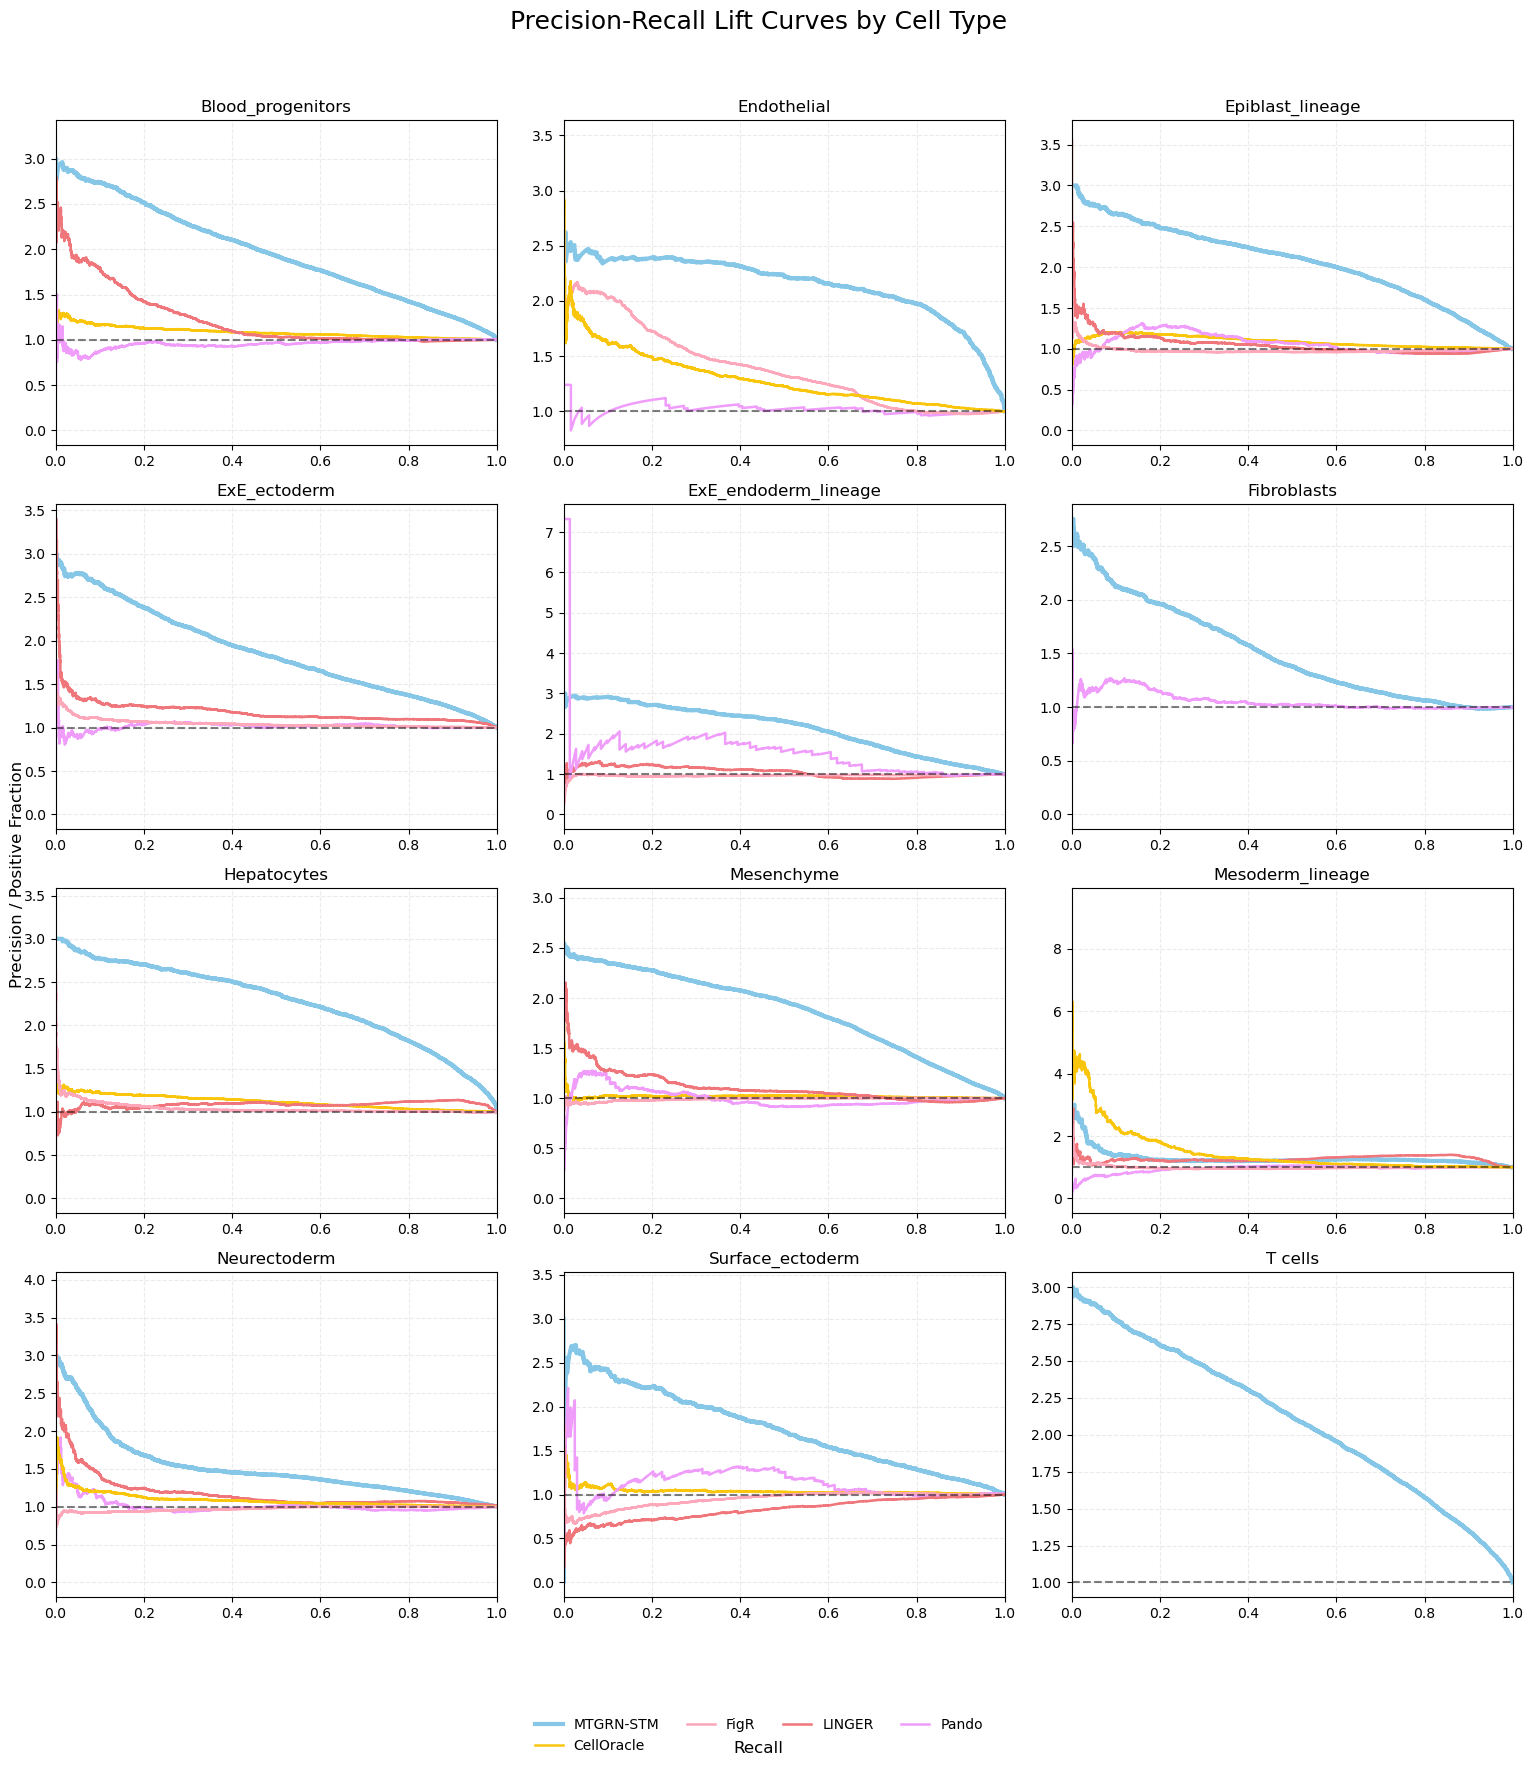

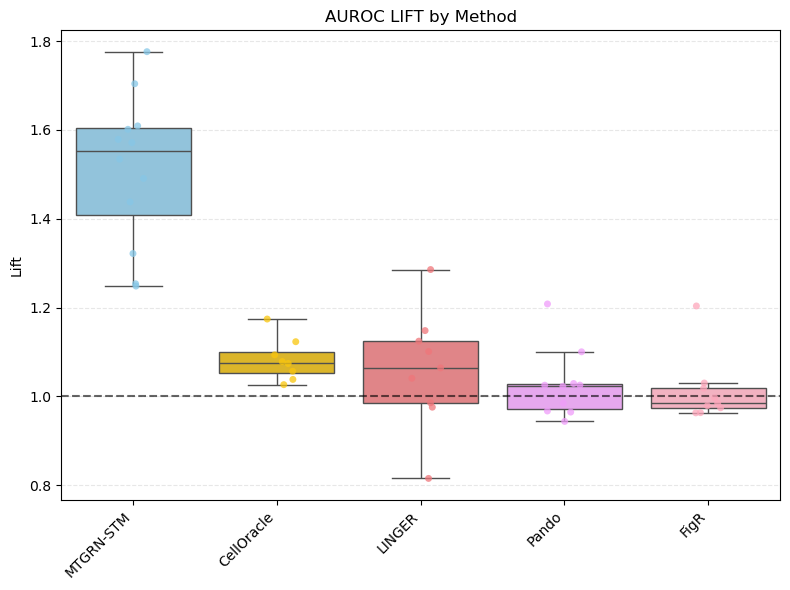

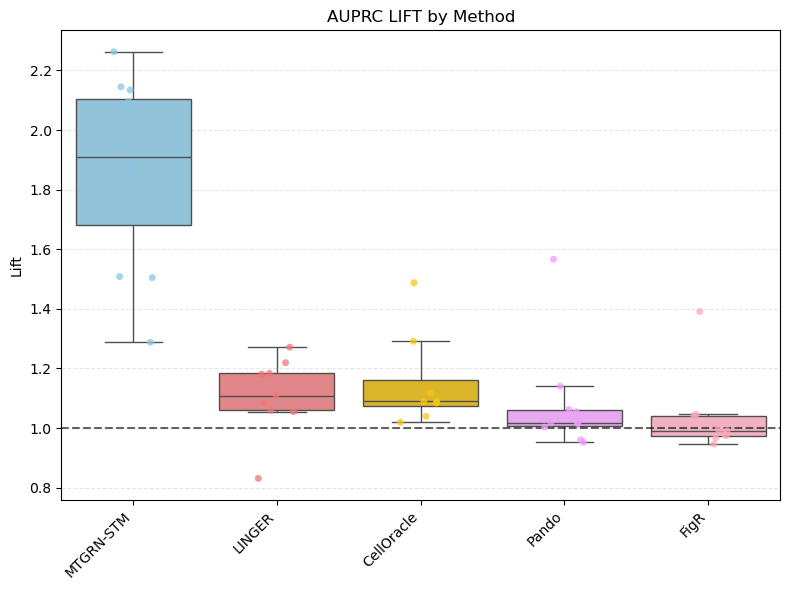

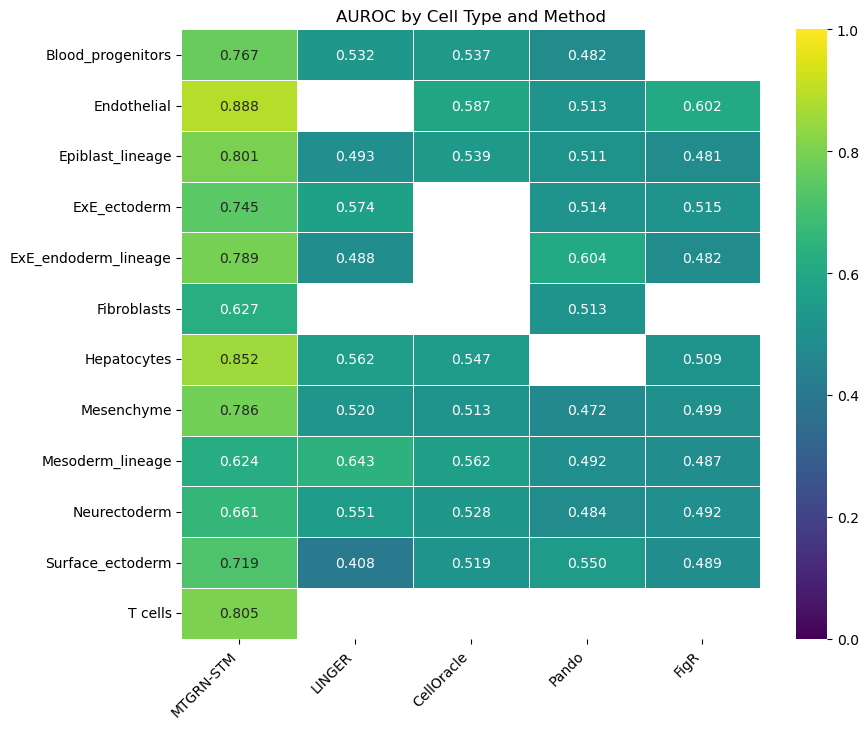

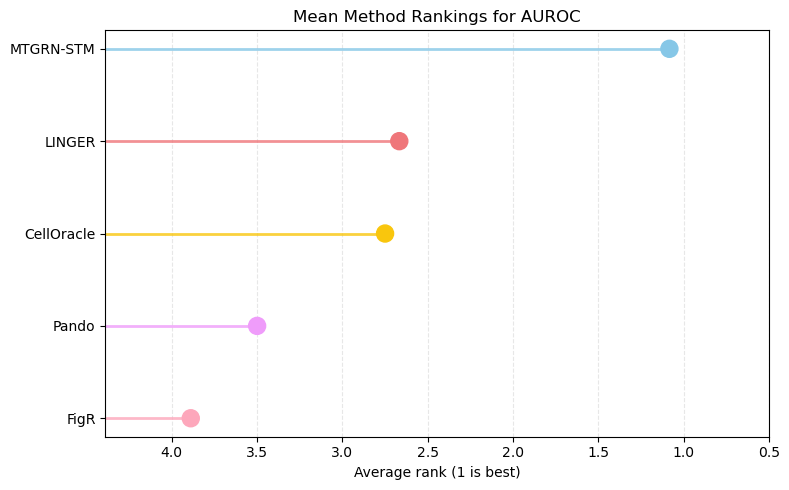

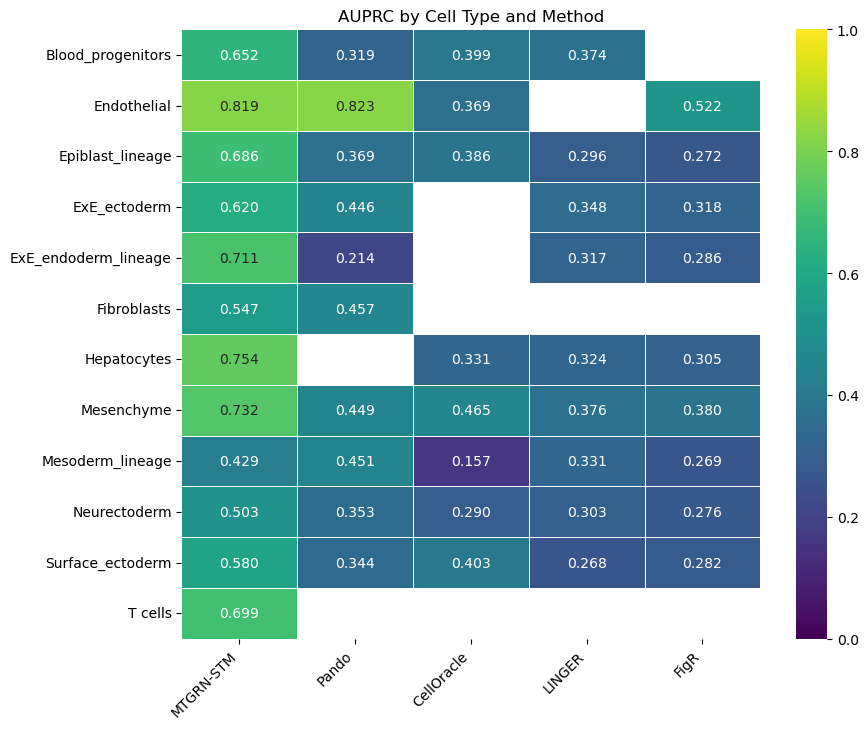

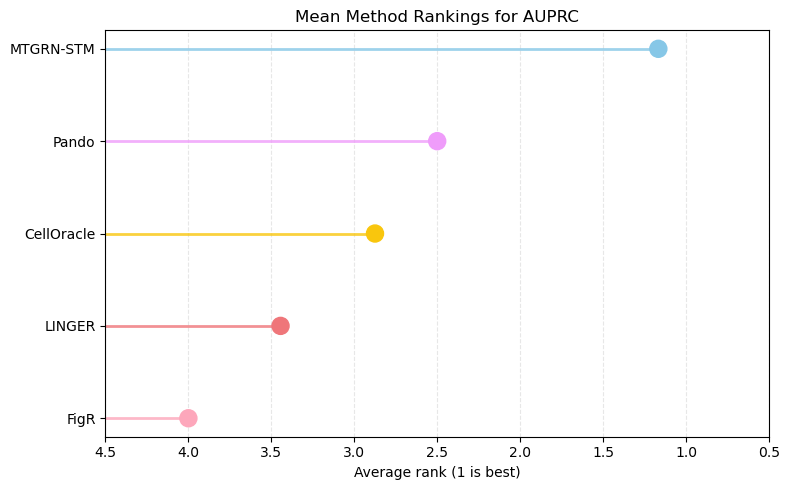

,method_name,cell_type,n_edges,positive_fraction,auroc,rand_auroc,auroc_lift,auprc,rand_auprc,auprc_lift
0,TF-TG Model (self-trained),Blood_progenitors,29487,0.333333,0.767136,0.5,1.534272,0.651953,0.333333,1.955859
1,CellOracle,Blood_progenitors,32761,0.367876,0.537024,0.5,1.074048,0.398826,0.367876,1.084129
2,LINGER,Blood_progenitors,11049,0.306815,0.532044,0.5,1.064087,0.374117,0.306815,1.219356
3,Pando,Blood_progenitors,3036,0.332016,0.482329,0.5,0.964658,0.318984,0.332016,0.960750
4,TF-TG Model (self-trained),Endothelial,4704,0.381590,0.888137,0.5,1.776273,0.818527,0.381590,2.145042
5,FigR,Endothelial,16310,0.375107,0.601801,0.5,1.203603,0.521673,0.375107,1.390731
6,CellOracle,Endothelial,13329,0.285468,0.587076,0.5,1.174152,0.368587,0.285468,1.291169
7,Pando,Endothelial,150,0.806667,0.512682,0.5,1.025363,0.822517,0.806667,1.019650
8,TF-TG Model (self-trained),Epiblast_lineage,19278,0.333333,0.800720,0.5,1.601439,0.686218,0.333333,2.058654
9,CellOracle,Epiblast_lineage,31795,0.354553,0.539186,0.5,1.078371,0.386026,0.354553,1.088769


Saved comparison plots and metrics to /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER/checkpoints/celltype_tf_tg/celltype_joint_3881696_20260916_181748_296478/self_trained_method_comparison_plots


In [25]:
import math

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

# Use the same method name and colors as test_tf_tg_predictions.ipynb.
SELF_MODEL_METHOD = "TF-TG Model (self-trained)"
method_display_name_map = {SELF_MODEL_METHOD: "MTGRN-STM"}
method_color_dict = {
    SELF_MODEL_METHOD: "#86C7E7",
    "LINGER": "#EF767A",
    "CellOracle": "#F9C60D",
    "Pando": "#EF9CFA",
    "SCENIC+": "#82EC32",
    "FigR": "#FDA7BB",
    "GRaNIE": "#F98637",
}

comparison_plot_dir = (
    model_checkpoint.parent.parent / "self_trained_method_comparison_plots"
)
comparison_plot_dir.mkdir(parents=True, exist_ok=True)

# method_grns contains the external methods. Add the evaluated TF-TG model,
# keeping one DataFrame per (method, cell type). Each method is scored over the
# labeled edge set already prepared above; unscored edges are not zero-filled.
comparison_grns = {
    key: frame.copy() for key, frame in method_grns.items()
}
for cell_type, frame in evaluation_grn.groupby("CellType", sort=True):
    comparison_grns[(SELF_MODEL_METHOD, cell_type)] = frame.copy()

available_methods = sorted({method for method, _ in comparison_grns})
method_order = (
    ([SELF_MODEL_METHOD] if SELF_MODEL_METHOD in available_methods else [])
    + [method for method in available_methods if method != SELF_MODEL_METHOD]
)
fallback_colors = sns.color_palette("tab10", n_colors=max(len(method_order), 1))
for index, method in enumerate(method_order):
    method_color_dict.setdefault(method, fallback_colors[index])

comparison_frames = {}
metric_rows = []
for (method_name, cell_type), frame in sorted(comparison_grns.items()):
    required = {"Score", "Label"}
    missing = required - set(frame.columns)
    if missing:
        logging.warning(
            "Skipping %s / %s; missing columns: %s",
            method_name, cell_type, sorted(missing),
        )
        continue

    clean = frame.copy()
    clean["Score"] = pd.to_numeric(clean["Score"], errors="coerce")
    clean["Label"] = pd.to_numeric(clean["Label"], errors="coerce")
    clean = clean.dropna(subset=["Score", "Label"]).copy()
    clean["Label"] = clean["Label"].astype(np.int8)

    if clean.empty or clean["Label"].nunique() < 2:
        logging.warning(
            "Skipping %s / %s; both label classes are required",
            method_name, cell_type,
        )
        continue

    labels = clean["Label"].to_numpy()
    scores = clean["Score"].to_numpy(dtype=float)
    auroc = roc_auc_score(labels, scores)
    auprc = average_precision_score(labels, scores)
    positive_fraction = float(labels.mean())

    comparison_frames[(method_name, cell_type)] = clean
    metric_rows.append({
        "method_name": method_name,
        "cell_type": cell_type,
        "n_edges": len(clean),
        "positive_fraction": positive_fraction,
        "auroc": auroc,
        "rand_auroc": 0.5,
        "auroc_lift": auroc / 0.5,
        "auprc": auprc,
        "rand_auprc": positive_fraction,
        "auprc_lift": auprc / positive_fraction,
    })

comparison_metric_df = pd.DataFrame(metric_rows)
if comparison_metric_df.empty:
    raise ValueError("No method/cell-type comparisons have both label classes")

all_comparison_figures = {}


def _display_method_name(method_name):
    return method_display_name_map.get(method_name, method_name)


def plot_method_metric_boxplot(metric_name):
    plot_df = comparison_metric_df.dropna(subset=[metric_name]).copy()
    order = (
        plot_df.groupby("method_name")[metric_name]
        .median().sort_values(ascending=False).index.tolist()
    )
    palette = {method: method_color_dict[method] for method in order}
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.boxplot(
        data=plot_df, x="method_name", y=metric_name,
        hue="method_name", order=order, hue_order=order,
        palette=palette, showfliers=False, legend=False, ax=ax,
    )
    sns.stripplot(
        data=plot_df, x="method_name", y=metric_name,
        hue="method_name", order=order, hue_order=order,
        palette=palette, dodge=False, jitter=0.15, alpha=0.75,
        size=5, legend=False, ax=ax,
    )
    for position, method in enumerate(order):
        median = plot_df.loc[plot_df["method_name"] == method, metric_name].median()
        ax.text(position, min(median + 0.045, 1.05), f"{median:.3f}",
                ha="center", va="bottom", fontsize=10)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(
        [_display_method_name(method) for method in order],
        rotation=45, ha="right",
    )
    ax.set_ylim(-0.02, 1.08)
    ax.set_xlabel("")
    ax.set_ylabel(metric_name.upper())
    ax.set_title(f"{metric_name.upper()} by Method")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    fig.tight_layout()
    return fig, ax


for metric_name in ("auroc", "auprc"):
    fig, ax = plot_method_metric_boxplot(metric_name)
    fig.savefig(
        comparison_plot_dir / f"{metric_name}_by_method_boxplot.png",
        dpi=300, bbox_inches="tight", facecolor="white",
    )
    all_comparison_figures[f"{metric_name}_boxplot"] = (fig, ax)
    plt.show()


def plot_cell_type_curve_panels(curve_kind, ncols=3):
    cell_types = sorted(comparison_metric_df["cell_type"].unique())
    nrows = math.ceil(len(cell_types) / ncols)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(5.2 * ncols, 4.5 * nrows), squeeze=False,
    )

    for ax, cell_type in zip(axes.flat, cell_types):
        cell_metrics = comparison_metric_df[
            comparison_metric_df["cell_type"] == cell_type
        ]
        metric_column = "auroc" if curve_kind == "roc" else "auprc"
        plotted_methods = (
            cell_metrics.sort_values(metric_column, ascending=False)["method_name"]
            .tolist()
        )
        for method_name in plotted_methods:
            clean = comparison_frames[(method_name, cell_type)]
            labels = clean["Label"].to_numpy()
            scores = clean["Score"].to_numpy(dtype=float)
            color = method_color_dict[method_name]
            linewidth = 3 if method_name == SELF_MODEL_METHOD else 1.8

            if curve_kind == "roc":
                x_values, y_values, _ = roc_curve(labels, scores)
            else:
                precision, recall, _ = precision_recall_curve(labels, scores)
                x_values = recall
                if curve_kind == "prc_lift":
                    y_values = precision / max(float(labels.mean()), 1e-12)
                else:
                    y_values = precision

            ax.plot(x_values, y_values, color=color, linewidth=linewidth)
            if curve_kind == "prc":
                ax.axhline(
                    float(labels.mean()), color=color, linestyle="--",
                    linewidth=0.8, alpha=0.45,
                )

        if curve_kind == "roc":
            ax.plot([0, 1], [0, 1], color="black", linestyle="--", alpha=0.5)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
        elif curve_kind == "prc":
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
        else:
            ax.axhline(1, color="black", linestyle="--", alpha=0.5)
            ax.set_xlim(0, 1)

        ax.set_title(cell_type)
        ax.grid(linestyle="--", alpha=0.25)

    for ax in axes.flat[len(cell_types):]:
        ax.set_visible(False)

    title_by_kind = {
        "roc": "ROC Curves by Cell Type",
        "prc": "Precision-Recall Curves by Cell Type",
        "prc_lift": "Precision-Recall Lift Curves by Cell Type",
    }
    y_label_by_kind = {
        "roc": "True Positive Rate",
        "prc": "Precision",
        "prc_lift": "Precision / Positive Fraction",
    }
    fig.suptitle(title_by_kind[curve_kind], fontsize=18)
    fig.supxlabel("False Positive Rate" if curve_kind == "roc" else "Recall")
    fig.supylabel(y_label_by_kind[curve_kind])

    legend_handles = [
        Line2D(
            [0], [0], color=method_color_dict[method],
            linewidth=3 if method == SELF_MODEL_METHOD else 1.8,
            label=_display_method_name(method),
        )
        for method in method_order
        if method in set(comparison_metric_df["method_name"])
    ]
    fig.legend(
        handles=legend_handles, loc="lower center", ncol=min(4, len(legend_handles)),
        bbox_to_anchor=(0.5, 0.005), frameon=False,
    )
    fig.tight_layout(rect=(0, 0.06, 1, 0.96))
    return fig, axes


for curve_kind in ("roc", "prc", "prc_lift"):
    fig, axes = plot_cell_type_curve_panels(curve_kind)
    fig.savefig(
        comparison_plot_dir / f"{curve_kind}_curves_by_cell_type.png",
        dpi=300, bbox_inches="tight", facecolor="white",
    )
    all_comparison_figures[f"{curve_kind}_curves"] = (fig, axes)
    plt.show()


def plot_lift_boxplot(lift_column):
    plot_df = comparison_metric_df.dropna(subset=[lift_column]).copy()
    order = (
        plot_df.groupby("method_name")[lift_column]
        .median().sort_values(ascending=False).index.tolist()
    )
    palette = {method: method_color_dict[method] for method in order}
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.boxplot(
        data=plot_df, x="method_name", y=lift_column,
        hue="method_name", order=order, hue_order=order,
        palette=palette, showfliers=False, legend=False, ax=ax,
    )
    sns.stripplot(
        data=plot_df, x="method_name", y=lift_column,
        hue="method_name", order=order, hue_order=order,
        palette=palette, dodge=False, jitter=0.15, alpha=0.75,
        size=5, legend=False, ax=ax,
    )
    ax.axhline(1, color="black", linestyle="--", alpha=0.6)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(
        [_display_method_name(method) for method in order],
        rotation=45, ha="right",
    )
    ax.set_xlabel("")
    ax.set_ylabel("Lift")
    ax.set_title(f"{lift_column.replace('_', ' ').upper()} by Method")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    fig.tight_layout()
    return fig, ax


for lift_column in ("auroc_lift", "auprc_lift"):
    fig, ax = plot_lift_boxplot(lift_column)
    fig.savefig(
        comparison_plot_dir / f"{lift_column}_by_method_boxplot.png",
        dpi=300, bbox_inches="tight", facecolor="white",
    )
    all_comparison_figures[f"{lift_column}_boxplot"] = (fig, ax)
    plt.show()


rank_summary = {}
for metric_name in ("auroc", "auprc"):
    rank_df = comparison_metric_df[["cell_type", "method_name", metric_name]].dropna().copy()
    rank_df["rank"] = (
        rank_df.groupby("cell_type")[metric_name]
        .rank(method="min", ascending=False)
    )
    average_rank = (
        rank_df.groupby("method_name", as_index=False)["rank"]
        .mean().rename(columns={"rank": "average_rank"})
        .sort_values("average_rank")
    )
    ordered_methods = average_rank["method_name"].tolist()

    metric_matrix = rank_df.pivot(
        index="cell_type", columns="method_name", values=metric_name,
    ).reindex(columns=ordered_methods)
    fig_heatmap, ax_heatmap = plt.subplots(
        figsize=(1.25 * len(ordered_methods) + 3, 0.45 * len(metric_matrix) + 2),
    )
    sns.heatmap(
        metric_matrix, annot=True, fmt=".3f", cmap="viridis",
        vmin=0, vmax=1, linewidths=0.5, linecolor="white", ax=ax_heatmap,
    )
    ax_heatmap.set_xticklabels(
        [_display_method_name(method) for method in ordered_methods],
        rotation=45, ha="right",
    )
    ax_heatmap.set_xlabel("")
    ax_heatmap.set_ylabel("")
    ax_heatmap.set_title(f"{metric_name.upper()} by Cell Type and Method")
    fig_heatmap.tight_layout()
    fig_heatmap.savefig(
        comparison_plot_dir / f"{metric_name}_method_heatmap.png",
        dpi=300, bbox_inches="tight", facecolor="white",
    )
    plt.show()

    fig_rank, ax_rank = plt.subplots(figsize=(8, 5))
    y_positions = np.arange(len(average_rank))
    max_rank = max(float(average_rank["average_rank"].max()) + 0.5, 1.5)
    colors = [method_color_dict[method] for method in ordered_methods]
    ax_rank.hlines(
        y_positions, max_rank, average_rank["average_rank"],
        color=colors, linewidth=2, alpha=0.8,
    )
    ax_rank.scatter(
        average_rank["average_rank"], y_positions,
        color=colors, s=150, zorder=3,
    )
    ax_rank.set_yticks(y_positions)
    ax_rank.set_yticklabels([_display_method_name(method) for method in ordered_methods])
    ax_rank.set_xlim(max_rank, 0.5)
    ax_rank.invert_yaxis()
    ax_rank.set_xlabel("Average rank (1 is best)")
    ax_rank.set_title(f"Mean Method Rankings for {metric_name.upper()}")
    ax_rank.grid(axis="x", linestyle="--", alpha=0.3)
    fig_rank.tight_layout()
    fig_rank.savefig(
        comparison_plot_dir / f"average_{metric_name}_rank_lollipop.png",
        dpi=300, bbox_inches="tight", facecolor="white",
    )
    plt.show()

    rank_summary[metric_name] = {
        "rank_data": rank_df,
        "average_rank": average_rank,
        "heatmap": (fig_heatmap, ax_heatmap),
        "lollipop": (fig_rank, ax_rank),
    }

all_comparison_figures["rank_summary"] = rank_summary
comparison_metric_df.to_csv(
    comparison_plot_dir / "comparison_metrics_by_cell_type.csv", index=False,
)
display(
    comparison_metric_df.sort_values(
        ["cell_type", "auroc"], ascending=[True, False],
    ).reset_index(drop=True)
)
print(f"Saved comparison plots and metrics to {comparison_plot_dir}")

### Other samples

In [ ]:
from sklearn.metrics import average_precision_score

def build_performance_dataframe(edge_frame, probabilities, labels):
    """Return edge predictions plus overall, per-cell-type, and macro metrics."""
    probabilities = torch.as_tensor(probabilities).detach().cpu().float().numpy()
    labels = torch.as_tensor(labels).detach().cpu().int().numpy()
    if len(edge_frame) != len(probabilities):
        raise ValueError(
            f"Frame has {len(edge_frame):,} rows but received "
            f"{len(probabilities):,} predictions"
        )
    frame_labels = edge_frame["label"].astype(int).to_numpy()
    if not np.array_equal(frame_labels, labels):
        raise ValueError("Prediction labels are not aligned with the edge-frame rows")

    predictions = edge_frame[[
        "sample_id", "cell_type", "tf_name", "tg_id", "label"
    ]].reset_index(drop=True).copy()
    predictions["probability"] = probabilities
    predictions["predicted_label"] = (probabilities >= 0.5).astype(np.int8)

    def summarize(scope, name, frame):
        y = frame["label"].astype(int).to_numpy()
        p = frame["probability"].to_numpy()
        has_both_labels = np.unique(y).size == 2
        return {
            "scope": scope,
            "cell_type": name,
            "n_edges": len(frame),
            "n_positive": int(y.sum()),
            "positive_fraction": float(y.mean()),
            "loss": float(nn.functional.binary_cross_entropy(
                torch.from_numpy(p).float(), torch.from_numpy(y).float(),
            )),
            "auroc": (
                float(roc_auc_score(y, p)) if has_both_labels else float("nan")
            ),
            "auprc": (
                float(average_precision_score(y, p))
                if has_both_labels else float("nan")
            ),
            "accuracy": float(((p >= 0.5).astype(int) == y).mean()),
        }

    rows = [summarize("overall", "all", predictions)]
    rows.extend(
        summarize("cell_type", cell_type, frame)
        for cell_type, frame in predictions.groupby("cell_type", sort=True)
    )
    performance = pd.DataFrame(rows)
    per_cell_type = performance[performance["scope"] == "cell_type"]
    macro = {
        "scope": "macro_cell_type",
        "cell_type": "mean",
        "n_edges": int(per_cell_type["n_edges"].sum()),
        "n_positive": int(per_cell_type["n_positive"].sum()),
    }
    for column in ["positive_fraction", "loss", "auroc", "auprc", "accuracy"]:
        macro[column] = float(per_cell_type[column].mean())
    performance = pd.concat(
        [performance, pd.DataFrame([macro])], ignore_index=True
    )
    return predictions, performance

inputs = pd.concat([ds.inputs for ds in test_dataset.datasets], ignore_index=True)
test_predictions, test_performance_df = build_performance_dataframe(
    inputs, eval_probs, eval_labels
)
test_predictions.to_parquet(
    model_checkpoint.parent.parent / "test_predictions.parquet", index=False
)
test_performance_df.to_csv(
    model_checkpoint.parent.parent / "test_performance_by_celltype.csv", index=False
)
print(f"Evaluation results on test set: Loss = {eval_loss:.4f}, AUROC = {eval_auroc:.4f}")
display(test_performance_df.round(4))

Evaluation results on test set: Loss = 0.5538, AUROC = 0.7472


,scope,cell_type,n_edges,n_positive,positive_fraction,loss,auroc,auprc,accuracy
0,overall,all,248010,85257,0.3438,0.5538,0.7472,0.6393,0.7325
1,cell_type,Blood_progenitors,29487,9829,0.3333,0.5348,0.7605,0.6359,0.7374
2,cell_type,Endothelial,4704,1795,0.3816,0.4476,0.8798,0.8053,0.8102
3,cell_type,Epiblast_lineage,19278,6426,0.3333,0.5139,0.7916,0.6727,0.7565
4,cell_type,ExE_ectoderm,29367,9789,0.3333,0.5516,0.7364,0.6144,0.7262
5,cell_type,ExE_endoderm_lineage,6192,2064,0.3333,0.5164,0.7874,0.7036,0.7775
6,cell_type,Fibroblasts,17550,6379,0.3635,0.7624,0.6315,0.5519,0.6847
7,cell_type,Hepatocytes,19320,6440,0.3333,0.4640,0.8386,0.7303,0.7821
8,cell_type,Mesenchyme,30597,12030,0.3932,0.5540,0.7761,0.7223,0.7335
9,cell_type,Mesoderm_lineage,4854,1618,0.3333,0.6500,0.6100,0.4551,0.6251


### External evaluation

Set `evaluation_tissue` and `evaluation_sample` to evaluate any existing processed dataset. The selected cell types held out from training are evaluated on their complete edge sets, combining train-, validation-, and test-chromosome rows. The checkpoint applies its saved training scaler during inference; no scaler is refit here.

In [ ]:
# import importlib
# import scripts.train_tf_to_tg_celltype_model as train_module
# importlib.reload(train_module)

torch.cuda.set_per_process_memory_fraction(1.0, device=0) 

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:64"

from types import SimpleNamespace
from torch.utils.data import DataLoader
from scripts.train_tf_to_tg_celltype_model import (
    TFTGEdgeBagDataset,
    load_or_precompute_binding_scores,
    prepare_data,
)

import gc

torch.cuda.empty_cache(); gc.collect()

# Change only these two values to select an existing processed dataset.
evaluation_tissue, evaluation_sample = "mESC", "E8.5_rep1"

# Set this to True to use all cell types, or False to use only the holdout cell types.
use_all_celltypes = True

source_key = f"{evaluation_tissue}__{evaluation_sample}"
run_cache_dir = Path(test_run_config["cache_dir"])
source_cache_dir = run_cache_dir / "prepared_sources" / source_key
evaluation_data_path = (
    Path(test_run_config["data_dir"]) / "processed"
    / evaluation_tissue / evaluation_sample / "multiome_processed.h5mu"
)
if not evaluation_data_path.is_file():
    processed_dir = Path(test_run_config["data_dir"]) / "processed"
    available_datasets = sorted(
        str(path.parent.relative_to(processed_dir)).replace(os.sep, ":")
        for path in processed_dir.glob("*/*/multiome_processed.h5mu")
    )
    raise FileNotFoundError(
        f"Evaluation dataset does not exist: {evaluation_data_path}. "
        f"Available tissue:sample datasets: {available_datasets}"
    )

evaluation_dir = (
    model_checkpoint.parent.parent / "holdout_evaluation" / source_key
)
evaluation_dir.mkdir(parents=True, exist_ok=True)

cache_manifest_path = run_cache_dir / "cache_manifest.json"
with open(cache_manifest_path) as handle:
    prepared_cache_manifest = json.load(handle)

evaluation_args = SimpleNamespace(
    species=test_run_config["species"],
    tissue=evaluation_tissue,
    sample_name=evaluation_sample,
    data_dir=Path(test_run_config["data_dir"]),
    gene_ref_file=None,
    output_dir=source_cache_dir,
    num_workers=test_run_config["num_workers"],
    max_cells_per_pair=test_run_config["max_cells_per_pair"],
    max_peaks_per_tg=test_run_config["max_peaks_per_tg"],
    peak_flank_size=test_run_config["peak_flank_size"],
    true_false_ratio=test_run_config["true_false_ratio"],
    balance_tf=test_run_config["balance_tf"],
    balance_tg=test_run_config["balance_tg"],
    min_cells_per_slice=test_run_config["min_cells_per_slice"],
    min_tfs_per_slice=test_run_config["min_tfs_per_slice"],
    max_gt_density=test_run_config["max_gt_density"],
    seed=test_run_config["seed"],
    prepared_cache_manifest=prepared_cache_manifest
)

(
    evaluation_splits, evaluation_cell_pools, evaluation_atac_mat, evaluation_rna_mat,
    evaluation_peak_tensor, evaluation_embedding_path, evaluation_mask_path,
) = prepare_data(evaluation_args)

holdout_celltypes = set(test_run_config.get("holdout_celltype", []))
if not holdout_celltypes:
    raise ValueError("The selected run did not hold out any cell types")

holdout_frames = []
for chromosome_split in ("train", "val", "test"):
    split_frame = evaluation_splits.get(chromosome_split)
    
    if use_all_celltypes == True:
        split_frame["chromosome_split"] = chromosome_split
        holdout_frames.append(split_frame)
        
    else:
        if split_frame is None or split_frame.empty:
            continue
        
        split_holdouts = split_frame[
            split_frame["cell_type"].isin(holdout_celltypes)
        ].copy()
        
        if not split_holdouts.empty:
            split_holdouts["chromosome_split"] = chromosome_split
            holdout_frames.append(split_holdouts)

if not holdout_frames:
    raise ValueError(
        f"None of {sorted(holdout_celltypes)} occur in "
        f"{evaluation_tissue}:{evaluation_sample}"
    )
evaluation_holdout_frame = pd.concat(holdout_frames, ignore_index=True)

max_evaluation_edges = 10_000

evaluation_subset_frame = (
    evaluation_holdout_frame
    .sample(
        n=min(max_evaluation_edges, len(evaluation_holdout_frame)),
        random_state=evaluation_args.seed,
        replace=False,
    )
    .reset_index(drop=True)
)

print(
    f"Selected {len(evaluation_subset_frame):,} of "
    f"{len(evaluation_holdout_frame):,} evaluation edges"
)

evaluated_holdouts = sorted(evaluation_holdout_frame["cell_type"].unique())
missing_source_holdouts = sorted(holdout_celltypes - set(evaluated_holdouts))

trained_tf_peak_model = trained_tf_peak_model.to(device)
binding_tf_embeddings = tf_embeddings_tensor.to(device=device, dtype=torch.float32)
binding_tf_masks = tf_mask_tensor.to(device=device, dtype=torch.bool)
evaluation_binding_peak_tensor = evaluation_peak_tensor.to(device=device, dtype=torch.uint8)

try:
    binding_result = load_or_precompute_binding_scores(
        "evaluation_subset",
        evaluation_subset_frame,
        trained_tf_peak_model,
        prepared_dir=evaluation_dir / "prepared",
        tf_dna_checkpoint=Path(test_run_config["tf_dna_checkpoint"]),
        tf_embeddings_tensor=binding_tf_embeddings,
        tf_mask_tensor=binding_tf_masks,
        atac_peak_tensor=evaluation_binding_peak_tensor,
        max_peaks_per_tg=evaluation_args.max_peaks_per_tg,
        device=device,
        chunk_size=test_run_config.get("binding_chunk_size", 2048),
        full_tqdm=True,
    )

    if len(binding_result) == 2:
        evaluation_binding_scores, evaluation_binding_cache = binding_result
        gpu_usage = {}
    else:
        (
            evaluation_binding_scores,
            evaluation_binding_cache,
            gpu_usage,
        ) = binding_result
finally:
    del evaluation_binding_peak_tensor, binding_tf_embeddings, binding_tf_masks
    trained_tf_peak_model = trained_tf_peak_model.cpu()
    if device.type == "cuda":
        torch.cuda.empty_cache()

evaluation_subset_dataset = TFTGEdgeBagDataset(
    evaluation_subset_frame,
    tf_embeddings_tensor=None,
    tf_mask_tensor=None,
    atac_peak_tensor=evaluation_peak_tensor,
    atac_mat=evaluation_atac_mat,
    rna_mat=evaluation_rna_mat,
    cell_pools=evaluation_cell_pools,
    max_peaks_per_tg=evaluation_args.max_peaks_per_tg,
    resample_max_cells_per_pair=evaluation_args.max_cells_per_pair,
    resample_cells=False,
    binding_scores=evaluation_binding_scores,
    seed=evaluation_args.seed,
)
evaluation_subset_dataloader = DataLoader(
    evaluation_subset_dataset,
    batch_size=test_run_config["batch_size"],
    shuffle=False,
    num_workers=test_run_config["num_workers"],
    persistent_workers=test_run_config["num_workers"] > 0,
    pin_memory=device.type == "cuda",
    drop_last=False,
)

evaluation_build_config = {
    key: str(value) if isinstance(value, Path) else value
    for key, value in vars(evaluation_args).items()
}
evaluation_build_config.update({
    "source_cache_dir": str(source_cache_dir),
    "binding_cache": str(evaluation_binding_cache),
    "requested_holdout_celltypes": sorted(holdout_celltypes),
    "evaluated_holdout_celltypes": evaluated_holdouts,
    "missing_source_holdout_celltypes": missing_source_holdouts,
    "chromosome_splits": ["train", "val", "test"],
    "n_edges": len(evaluation_subset_frame),
})
(evaluation_dir / "evaluation_config.json").write_text(
    json.dumps(evaluation_build_config, indent=2)
)
print(
    f"Built {len(evaluation_subset_dataset):,} subset holdout edges for "
    f"{evaluation_tissue} {evaluation_sample}: {evaluated_holdouts}; "
    f"{len(evaluation_subset_dataloader):,} batches"
)


INFO:root: Building for Sample: E8.5_rep1, Tissue: mESC

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
INFO:root:Loaded MuData object:
INFO:

RNA: (8107, 18796)
ATAC: (8107, 216732)
Sequence peaks: 216732
Annotated cell types: 34


INFO:root:Extracted GTF attributes: ['gene_id', 'gene_version', 'gene_name', 'gene_source', 'gene_biotype', 'transcript_id', 'transcript_version', 'transcript_name', 'transcript_source', 'transcript_biotype', 'tag', 'transcript_support_level', 'exon_number', 'exon_id', 'exon_version', 'protein_id', 'protein_version', 'ccds_id']
INFO:root:  - Train set: 62,426 genes (chroms 1-15)
INFO:root:  - Validation set: 5,700 genes (chroms 16-17)
INFO:root:  - Test set: 4,099 genes (chroms 18-19)
INFO:root:TFs with embeddings and RNA: 406
INFO:root:mESC_label_map.tsv: 21 slices from 37 annotated types
INFO:root:Creating centered peak one-hot encodings for ATAC peaks...


                         slice  cells  types  edges  TFs   TGs  density           use
              Mesoderm_lineage   1723      8  25708    8 12336    0.260           yes
          ExE_endoderm_lineage   1120      3  33001    9 13254    0.277           yes
  Forebrain_Midbrain_Hindbrain    903      1  72018   26 14052    0.197           yes
                     Erythroid    729      3  59091   14 15694    0.269           yes
                           NMP    579      1  11460    2  8204    0.698   too few TFs
              Surface_ectoderm    578      1  46351   13 11855    0.301           yes
                    Mesenchyme    538      1 196656   34 16624    0.348           yes
                   Spinal_cord    391      1  26472    7 11868    0.319           yes
                           Gut    342      1   5494    2  4957    0.554   too few TFs
                Cardiomyocytes    254      1  36883   10 13139    0.281           yes
                  ExE_ectoderm    223      1 151246   

One-hot peaks:   0%|                                                                          | 0/216732 [00:0…

INFO:root:Cardiomyocytes: 254 cells from 1 annotated types, 36,883 GT edges, 10 TFs
INFO:root:Endothelium: 198 cells from 1 annotated types, 27,351 GT edges, 6 TFs
INFO:root:Erythroid: 729 cells from 3 annotated types, 59,091 GT edges, 14 TFs
INFO:root:ExE_ectoderm: 223 cells from 1 annotated types, 151,246 GT edges, 34 TFs
INFO:root:ExE_endoderm_lineage: 1,120 cells from 3 annotated types, 33,001 GT edges, 9 TFs
INFO:root:Forebrain_Midbrain_Hindbrain: 903 cells from 1 annotated types, 72,018 GT edges, 26 TFs
INFO:root:Intermediate_mesoderm: 132 cells from 1 annotated types, 29,834 GT edges, 7 TFs
INFO:root:Mesenchyme: 538 cells from 1 annotated types, 196,656 GT edges, 34 TFs
INFO:root:Mesoderm_lineage: 1,723 cells from 8 annotated types, 25,708 GT edges, 8 TFs
INFO:root:Spinal_cord: 391 cells from 1 annotated types, 26,472 GT edges, 7 TFs
INFO:root:Surface_ectoderm: 578 cells from 1 annotated types, 46,351 GT edges, 13 TFs
INFO:root:mESC:E8.5_rep1 saved prepared inputs to /gpfs/Labs/

Selected 10,000 of 2,035,474 evaluation edges


Binding scores: 100%|█| 217/217 [02:01<00:00,  1.78it/s, pairs_processed=222121/222121, gpu_res=40.74GB, gpu_alloc=5.09GB
INFO:root:evaluation_subset: cached binding scores (10000, 25) at /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER/checkpoints/celltype_tf_tg/celltype_joint_3881696_20260916_181748_296478/holdout_evaluation/mESC__E8.5_rep1/prepared/binding_scores_evaluation_subset_7d619814a24d638e.pt


222,121 distinct (TF, peak) pairs for 224,012 slots across 10,000 edges (1.0 MB)
Built 10,000 subset holdout edges for mESC E8.5_rep1: ['Cardiomyocytes', 'Endothelium', 'Erythroid', 'ExE_ectoderm', 'ExE_endoderm_lineage', 'Forebrain_Midbrain_Hindbrain', 'Intermediate_mesoderm', 'Mesenchyme', 'Mesoderm_lineage', 'Spinal_cord', 'Surface_ectoderm']; 20 batches


In [ ]:
gpu_usage_df = pd.DataFrame.from_dict(gpu_usage, orient='index')
gpu_usage_df

,time,reserved,allocated
0,0.022686,18.066964,16.384498
2048,1.057265,82.913001,16.384506
4096,2.164138,82.913001,16.384506
6144,3.270982,82.913001,16.384506
8192,4.378761,82.913001,16.384506
...,...,...,...
5115904,2822.491305,82.913001,16.384506
5117952,2823.621642,82.913001,16.384506
5120000,2824.752089,82.913001,16.384506
5122048,2825.882480,82.913001,16.384506


In [ ]:
from sklearn.metrics import average_precision_score

trained_model = trained_model.to(device)

subset_loss, subset_auroc, subset_probs, subset_labels = evaluate(
    trained_model,
    evaluation_subset_dataloader,
)

print(
    f"{evaluation_tissue} {evaluation_sample} subset "
    f"({len(evaluation_subset_frame):,} edges): "
    f"loss={subset_loss:.4f}; AUROC={subset_auroc:.4f}"
)

evaluation_predictions = evaluation_subset_frame[[
    "sample_id", "cell_type", "chromosome_split",
    "tf_name", "tg_id", "label"
]].copy()
evaluation_predictions["probability"] = subset_probs.numpy()
evaluation_predictions["predicted_label"] = (
    evaluation_predictions["probability"] >= 0.5
).astype(np.int8)

def summarize_prediction_group(scope, name, frame):
    labels = frame["label"].astype(int).to_numpy()
    probabilities = frame["probability"].to_numpy()
    has_both_labels = np.unique(labels).size == 2
    return {
        "scope": scope,
        "cell_type": name,
        "n_edges": len(frame),
        "n_positive": int(labels.sum()),
        "positive_fraction": float(labels.mean()),
        "loss": float(nn.functional.binary_cross_entropy(
            torch.from_numpy(probabilities).float(),
            torch.from_numpy(labels).float(),
        )),
        "auroc": (
            float(roc_auc_score(labels, probabilities))
            if has_both_labels else float("nan")
        ),
        "auprc": (
            float(average_precision_score(labels, probabilities))
            if has_both_labels else float("nan")
        ),
        "accuracy": float(
            ((probabilities >= 0.5).astype(int) == labels).mean()
        ),
    }

metric_rows = [summarize_prediction_group(
    "overall", "all", evaluation_predictions
)]
metric_rows.extend(
    summarize_prediction_group("cell_type", cell_type, frame)
    for cell_type, frame in evaluation_predictions.groupby("cell_type", sort=True)
)
evaluation_metrics = pd.DataFrame(metric_rows)
cell_type_metrics = evaluation_metrics[evaluation_metrics["scope"] == "cell_type"]
macro_row = pd.DataFrame([{
    "scope": "macro_cell_type",
    "cell_type": "mean",
    "n_edges": int(cell_type_metrics["n_edges"].sum()),
    "n_positive": int(cell_type_metrics["n_positive"].sum()),
    "positive_fraction": float(cell_type_metrics["positive_fraction"].mean()),
    "loss": float(cell_type_metrics["loss"].mean()),
    "auroc": float(cell_type_metrics["auroc"].mean()),
    "auprc": float(cell_type_metrics["auprc"].mean()),
    "accuracy": float(cell_type_metrics["accuracy"].mean()),
}])
evaluation_metrics = pd.concat([evaluation_metrics, macro_row], ignore_index=True)

evaluation_predictions.to_parquet(
    evaluation_dir / "full_holdout_predictions.parquet", index=False
)
evaluation_metrics.to_csv(
    evaluation_dir / "full_holdout_metrics.csv", index=False
)
print(
    f"{evaluation_tissue} {evaluation_sample} subset holdout loss: "
    f"{subset_loss:.4f}; AUROC: {subset_auroc:.4f}"
)
display(evaluation_metrics.round(4))

mESC E8.5_rep1 subset (10,000 edges): loss=0.5769; AUROC=0.7142
mESC E8.5_rep1 subset holdout loss: 0.5769; AUROC: 0.7142


,scope,cell_type,n_edges,n_positive,positive_fraction,loss,auroc,auprc,accuracy
0,overall,all,10000,3391,0.3391,0.5769,0.7142,0.5802,0.7087
1,cell_type,Cardiomyocytes,535,184,0.3439,0.7791,0.5785,0.4788,0.5832
2,cell_type,Endothelium,337,125,0.3709,0.5505,0.7900,0.6885,0.7270
3,cell_type,Erythroid,860,268,0.3116,0.5359,0.7445,0.5997,0.7198
4,cell_type,ExE_ectoderm,2205,716,0.3247,0.5488,0.7234,0.6093,0.7329
5,cell_type,ExE_endoderm_lineage,455,166,0.3648,0.5773,0.7349,0.5950,0.6901
6,cell_type,Forebrain_Midbrain_Hindbrain,1011,349,0.3452,0.6132,0.6623,0.5695,0.6746
7,cell_type,Intermediate_mesoderm,449,157,0.3497,0.5937,0.7210,0.6138,0.7082
8,cell_type,Mesenchyme,2759,966,0.3501,0.5577,0.7408,0.6293,0.7242
9,cell_type,Mesoderm_lineage,386,116,0.3005,0.6659,0.5811,0.3657,0.6295


In [ ]:
evaluation_predictions

,sample_id,cell_type,chromosome_split,tf_name,tg_id,label,probability,predicted_label
0,E7.5_rep2,Neurectoderm,train,FOXO3,SLC41A2,True,0.213665,0
1,E7.5_rep2,ExE_ectoderm,train,BBX,SYNE3,False,0.184449,0
2,E7.5_rep2,Mesoderm_lineage,train,POU2F1,TMEM168,True,0.328463,0
3,E7.5_rep2,ExE_ectoderm,val,EOMES,ARL6,False,0.446480,0
4,E7.5_rep2,Epiblast_lineage,train,TET1,ZFP988,False,0.159446,0
...,...,...,...,...,...,...,...,...
9995,E7.5_rep2,Blood_progenitors,train,RUNX1,PLEKHH3,True,0.417211,0
9996,E7.5_rep2,Blood_progenitors,train,GATA2,CPA2,False,0.708691,1
9997,E7.5_rep2,Blood_progenitors,train,CEBPB,KIF21B,False,0.616154,1
9998,E7.5_rep2,Neurectoderm,train,NPAS3,UGP2,False,0.138455,0


#### Generate predicted GRNs

Each row is a predicted TF-to-target-gene edge. `Score` is the model probability for that edge.

In [ ]:
grn_columns = ["CellType", "Source", "Target", "Score"]
evaluation_grn = (
    evaluation_predictions
    .rename(columns={
        "cell_type": "CellType",
        "tf_name": "Source",
        "tg_id": "Target",
        "probability": "Score",
    })
    .loc[:, grn_columns]
    .assign(
        Source=lambda frame: frame["Source"].astype(str).str.upper(),
        Target=lambda frame: frame["Target"].astype(str).str.upper(),
    )
)

display(evaluation_grn.head())

,CellType,Source,Target,Score
0,Neurectoderm,FOXO3,SLC41A2,0.213665
1,ExE_ectoderm,BBX,SYNE3,0.184449
2,Mesoderm_lineage,POU2F1,TMEM168,0.328463
3,ExE_ectoderm,EOMES,ARL6,0.446480
4,Epiblast_lineage,TET1,ZFP988,0.159446


## Combining Samples

In [ ]:
from copy import copy
from collections import defaultdict
from torch.utils.data import ConcatDataset

datasets_by_split = defaultdict(list)
source_frames = defaultdict(dict)

dataset_specs = [
    {"tissue": "mouse_liver", "sample_name": "liver_sample"},
    {"tissue": "mESC", "sample_name": "E7.5_rep1"},
]

binding_model = trained_tf_peak_model.to(device)
binding_tf_embeddings = tf_embeddings_tensor.to(device=device, dtype=torch.float32)
binding_tf_masks = tf_mask_tensor.to(device=device, dtype=torch.bool)

args = SimpleNamespace(
    species=None,
    tissue=None,
    sample_name=None,
    data_dir=Path(test_run_config["data_dir"]),
    gene_ref_file=None,
    output_dir=evaluation_dir,
    num_workers=test_run_config["num_workers"],
    max_cells_per_pair=test_run_config["max_cells_per_pair"],
    max_peaks_per_tg=test_run_config["max_peaks_per_tg"],
    binding_chunk_size=test_run_config["binding_chunk_size"],
    scaler_edges_per_sample=test_run_config.get("scaler_edges_per_sample", 100_000),
    peak_flank_size=test_run_config["peak_flank_size"],
    true_false_ratio=test_run_config["true_false_ratio"],
    balance_tf=test_run_config["balance_tf"],
    balance_tg=test_run_config["balance_tg"],
    min_cells_per_slice=test_run_config["min_cells_per_slice"],
    min_tfs_per_slice=test_run_config["min_tfs_per_slice"],
    max_gt_density=test_run_config["max_gt_density"],
    tf_dna_checkpoint=Path(test_run_config["tf_dna_checkpoint"]),
    resample_cells=test_run_config["resample_cells"],
    seed=test_run_config["seed"],
)

for spec in dataset_specs:
    source_args = copy(args)
    source_args.tissue = spec["tissue"]
    source_args.sample_name = spec["sample_name"]
    source_args.output_dir = (
        args.output_dir
        / "prepared_sources"
        / f"{spec['tissue']}__{spec['sample_name']}"
    )
    source_args.output_dir.mkdir(parents=True, exist_ok=True)

    (
        splits,
        pools,
        atac,
        rna,
        peaks,
        embedding_path,
        mask_path,
    ) = prepare_data(source_args)
    binding_peak_tensor = peaks.to(device=device, dtype=torch.uint8)

    for split_name, frame in splits.items():
        if frame.empty:
            continue

        scores, cache_path = load_or_precompute_binding_scores(
            split_name,
            frame,
            binding_model,
            prepared_dir=source_args.output_dir / "prepared",
            tf_dna_checkpoint=args.tf_dna_checkpoint,
            tf_embeddings_tensor=binding_tf_embeddings,
            tf_mask_tensor=binding_tf_masks,
            atac_peak_tensor=binding_peak_tensor,
            max_peaks_per_tg=args.max_peaks_per_tg,
            device=device,
            chunk_size=args.binding_chunk_size,
        )

        dataset = TFTGEdgeBagDataset(
            frame,
            tf_embeddings_tensor=None,
            tf_mask_tensor=None,
            atac_peak_tensor=peaks,
            atac_mat=atac,
            rna_mat=rna,
            cell_pools=pools,
            max_peaks_per_tg=args.max_peaks_per_tg,
            resample_max_cells_per_pair=args.max_cells_per_pair,
            resample_cells=(
                split_name == "train" and args.resample_cells
            ),
            binding_scores=scores,
            seed=args.seed,
        )

        datasets_by_split[split_name].append(dataset)
        source_frames[split_name][spec["sample_name"]] = frame

    del binding_peak_tensor
    if device.type == "cuda":
        torch.cuda.empty_cache()

del binding_tf_embeddings, binding_tf_masks
binding_model = binding_model.cpu()
if device.type == "cuda":
    torch.cuda.empty_cache()

combined_datasets = {
    split: ConcatDataset(parts)
    for split, parts in datasets_by_split.items()
}

## Shared Input Normalization

The RNA and ATAC matrices are already normalized for library depth and transformed with `log1p`. This section fits one additional mean and standard deviation for TF expression, TG expression, and peak accessibility. Statistics use training edges only, sample the same number of unique edges from each source, include biological zeros, and exclude padded cells and peaks. The resulting values are passed to the model, which standardizes real entries during its forward pass and restores padding to zero.

In [ ]:
from torch.utils.data import DataLoader
from scripts.train_tf_to_tg_celltype_model import (
    fit_shared_input_scaler,
    make_balanced_scaler_dataset,
    validate_input_scaler,
)

normalization_dir = args.output_dir / "combined_samples"
normalization_dir.mkdir(parents=True, exist_ok=True)
scaler_path = normalization_dir / "input_scaler.json"
scaler_manifest_path = normalization_dir / "input_scaler_manifest.json"

train_parts = datasets_by_split["train"]
scaler_manifest = {
    "datasets": [
        f"{spec['tissue']}:{spec['sample_name']}" for spec in dataset_specs
    ],
    "scaler_train_datasets": [
        f"{spec['tissue']}:{spec['sample_name']}" for spec in dataset_specs
    ],
    "holdout_samples": [],
    "holdout_celltypes": [],
    "train_edges": [len(dataset) for dataset in train_parts],
    "edges_per_sample": args.scaler_edges_per_sample,
    "seed": args.seed,
    "input_space": "per_sample_depth_normalized_log1p_X",
}
cached_manifest = (
    json.loads(scaler_manifest_path.read_text())
    if scaler_manifest_path.exists() else None
)

if scaler_path.exists() and cached_manifest == scaler_manifest:
    input_scaler = validate_input_scaler(json.loads(scaler_path.read_text()))
    logging.info("Loaded shared input scaling from %s", scaler_path)
else:
    scaler_dataset = make_balanced_scaler_dataset(
        train_parts, args.scaler_edges_per_sample, args.seed
    )
    scaler_loader = DataLoader(
        scaler_dataset,
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=args.num_workers,
        persistent_workers=args.num_workers > 0,
        pin_memory=False,
        drop_last=False,
    )
    input_scaler = validate_input_scaler(fit_shared_input_scaler(scaler_loader))
    scaler_path.write_text(json.dumps(input_scaler, indent=2))
    scaler_manifest_path.write_text(json.dumps(scaler_manifest, indent=2))
    logging.info("Saved shared input scaling to %s", scaler_path)

scaler_hparams = {
    f"{name}_{stat}": input_scaler[name][stat]
    for name in ("tf_expression", "tg_expression", "peak_accessibility")
    for stat in ("mean", "std")
}
display(pd.DataFrame(input_scaler).T[["mean", "std", "count"]])
scaler_hparams


In [ ]:
from torch.utils.data import DataLoader, WeightedRandomSampler

train_parts = datasets_by_split["train"]

sample_weights = torch.cat([
    torch.full(
        (len(dataset),),
        1.0 / len(dataset),
        dtype=torch.double,
    )
    for dataset in train_parts
])

generator = torch.Generator().manual_seed(args.seed)

train_sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=sum(len(dataset) for dataset in train_parts),
    replacement=True,
    generator=generator,
)

use_cuda = torch.cuda.is_available()

train_loader = DataLoader(
    combined_datasets["train"],
    batch_size=args.batch_size,
    sampler=train_sampler,
    shuffle=False,
    num_workers=args.num_workers,
    persistent_workers=args.num_workers > 0,
    pin_memory=use_cuda,
    drop_last=False,
)

In [ ]:
val_loader = DataLoader(
    combined_datasets["val"],
    batch_size=args.batch_size,
    shuffle=False,
    num_workers=args.num_workers,
    persistent_workers=args.num_workers > 0,
    pin_memory=use_cuda,
)

test_loader = DataLoader(
    combined_datasets["test"],
    batch_size=args.batch_size,
    shuffle=False,
    num_workers=args.num_workers,
    persistent_workers=args.num_workers > 0,
    pin_memory=use_cuda,
)